# EDA of TMQM* for absorption spectrum prediction

This notebook's purpose is to conduct a comprehensive Exploratory Data Analysis (EDA) on the TMQM* dataset. The EDA will focus on understanding the features, their correlation, and their collective impact on the absorption spectrum prediction. Finally, we will compare and analyze the differences across various model outputs

In [1]:
import os
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

Imports:

In [2]:
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, HalvingRandomSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from typing import Callable, Dict
from gjepa.datasets.cv_vis.tmqmg_star import TMQMGStarDataset
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
from torch_geometric.loader import DataLoader
from scipy.stats import uniform, randint, loguniform
import shap
import yaml
from collections import Counter
from scipy.stats import pearsonr, spearmanr,entropy
import networkx as nx


from gjepa.datasets.cv_vis.tmqmg_star import TMQMGStarDataset
from gjepa.datasets.graph_level import load_graph
from gjepa.config import GraphLevelExperimentConfig
from gjepa.utils.pyg import create_transform
from gjepa.utils.graph_level import split_dataset


/home/nikodem/Workspace/2-sem-mgr/mgr/SpectoChem/venv/lib64/python3.12/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


## High level analysis for output pairs (single pair)

Firstly we read dataset to predict a single pairs (the maximum f value and the corresponding lambda):

In [3]:
tmqm_pair_dataset_config_path = "./config/dataset/TMQM_SPECTO_PAIRS.yaml" 

with open(tmqm_pair_dataset_config_path, 'r') as stream:
    pair_config = yaml.safe_load(stream)

pair_config['additional_loading_params']['num_states'] = 1
pair_config['additional_loading_params']['min_f_value'] = -1
print(pair_config)

{'name': 'TMQM_SPECTO', 'root_dir': 'data/datasets/TMQM_SPECTO', 'pre_transforms': {}, 'transforms': {'AddEdgesAndDistances': {'cutoff': 5.0}}, 'in_channels': 1, 'out_channels': 8, 'task_type': 'multiregression', 'split_ratios': [0.8, 0.1], 'metric_mode': 'min', 'main_metric': 'MAE', 'additional_loading_params': {'prediction_type': 'pairs', 'num_states': 1, 'vis_range': [380, 750], 'block_3_only': True, 'filter_type': 'all_visible_lambdas', 'min_f_value': -1, 'sort_by_max_f': True, 'standarize_lambda': True, 'standarize_f': True}}


In [4]:
def get_dataset_for(config):
    return load_graph(
        root_dir=config['root_dir'],
        name=config['name'],
        additional_loading_params=config['additional_loading_params'],
        pre_transform=create_transform(config['pre_transforms']),
        transform=create_transform(config['transforms']))

In [5]:
binary_pair_dataset = get_dataset_for(pair_config)

Loading dataset 'TMQM_SPECTO' from data/datasets/TMQM_SPECTO...
{'prediction_type': 'pairs', 'num_states': 1, 'vis_range': [380, 750], 'block_3_only': True, 'filter_type': 'all_visible_lambdas', 'min_f_value': -1, 'sort_by_max_f': True, 'standarize_lambda': True, 'standarize_f': True}


In [6]:
def pyg_dataset_info(dataset, max_examples=5):
    print(f"Number of graphs: {len(dataset)}")

    num_nodes, num_edges = [], []
    field_shapes = {}

    for i in range(min(len(dataset), max_examples)):
        data = dataset[i]
        num_nodes.append(data.num_nodes)
        num_edges.append(data.num_edges)

        for key, item in data:
            if hasattr(item, "shape"):
                field_shapes.setdefault(key, set()).add(tuple(item.shape))
            else:
                field_shapes.setdefault(key, set()).add(type(item))

    print(f"Average nodes: {sum(num_nodes)/len(num_nodes):.2f}")
    print(f"Average edges: {sum(num_edges)/len(num_edges):.2f}")
    print("\nFields and shapes (first few samples):")

    example_values = {}
    for i in range(min(len(dataset), max_examples)):
        data = dataset[i]
        for key, value in data:
            if key not in example_values:
                example_values[key] = []
            if isinstance(value, str):
                example_values[key].append(value)
            elif hasattr(value, "shape"):
                example_values[key].append(f"Tensor{tuple(value.shape)}")
            else:
                example_values[key].append(type(value).__name__)

    print("\nFields and example values:")
    for key, examples in example_values.items():
        print(f"  - {key}: {examples[:3]}")  

pyg_dataset_info(binary_pair_dataset)


Number of graphs: 16866
Average nodes: 70.80
Average edges: 2006.60

Fields and shapes (first few samples):

Fields and example values:
  - y: ['Tensor(1, 2)', 'Tensor(1, 2)', 'Tensor(1, 2)']
  - pos: ['Tensor(45, 3)', 'Tensor(70, 3)', 'Tensor(81, 3)']
  - z: ['Tensor(45,)', 'Tensor(70,)', 'Tensor(81,)']
  - smiles: ['', 'Cc1cc23->[Sc+3]4567(<-[CH2-][Si](C)(C)C)(<-[CH2-][Si](C)(C)C)<-n8cccc9cccc(-[c-]->4(c->5(C)c->62C)c->73s1)c98', 'CC(C)N1=C2(C)[N-](C(C)C)->[Sc+3]<-1<-234567(<-c1c2cc[cH-]cc-2ccc2ccccc2[cH-]->31)<-c1(C)c->4(C)c->5(C)[c-]->6(C)c->71C']
  - origin_id: ['DASFIQ', 'SIHZOC', 'BEZMIG']
  - CSD_code: ['DASFIQ', 'SIHZOC', 'BEZMIG']
  - edge_index: ['Tensor(2, 822)', 'Tensor(2, 1800)', 'Tensor(2, 2560)']
  - edge_weight: ['Tensor(822,)', 'Tensor(1800,)', 'Tensor(2560,)']


Firstly let focus on analysing the output:

In [7]:
binary_pair_train_ds, binary_pair_val_ds, binary_pair_test_ds = split_dataset(binary_pair_dataset, pair_config['split_ratios'])

In [8]:
def get_outputs_distribution(train_dataset):
    lambdas = []
    f_values = []

    for data in train_dataset:
        y = data.y.squeeze()

        if y.numel() % 2 == 0 and y.numel() > 1:
            pairs = y.reshape(-1, 2).cpu().numpy()
            lam = pairs[:, 0]
            f = pairs[:, 1]

        elif y.numel() == 1:
            continue

        else:
            continue

        lambdas.extend(lam.tolist())
        f_values.extend(f.tolist())

    lambdas = np.array(lambdas)
    f_values = np.array(f_values)
    return f_values, lambdas

def draw_outputs_distribution(f_values, lambdas, bins_f=100, bins_lambdas=100):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(lambdas, bins=bins_lambdas)
    plt.xlabel("Wavelength Lambda (nm)")
    plt.ylabel("Count")
    plt.title("Distribution of Wavelengths")

    plt.subplot(1, 2, 2)
    plt.hist(f_values, bins=bins_f, color="green")
    plt.xlabel("Oscillator Strength f")
    plt.ylabel("Count")
    plt.title("Distribution of f")
    plt.xlim(0, 2)  
    plt.tight_layout()

    plt.show()

def draw_outputs_distribution_filtered(f_values, lambdas, bins_f=100, bins_lambdas=100, min_f_values=0.2):
    f_values = np.array(f_values)
    lambdas = np.array(lambdas)

    mask = f_values >= min_f_values
    f_filtered = f_values[mask]
    lambdas_filtered = lambdas[mask]

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(lambdas_filtered, bins=bins_lambdas)
    plt.xlabel("Wavelength Lambda (nm)")
    plt.ylabel("Count")
    plt.title(f"Distribution of Wavelengths (f >= {min_f_values})")

    plt.subplot(1, 2, 2)
    plt.hist(f_filtered, bins=bins_f, color="green")
    plt.xlabel("Oscillator Strength f")
    plt.ylabel("Count")
    plt.title(f"Distribution of f (f >= {min_f_values})")
    plt.xlim(min_f_values, 2)
    plt.tight_layout()

    plt.show()

def draw_space_covering(f_values, lambdas, s=10, bins=40):
    f_values = np.array(f_values)
    lambdas = np.array(lambdas)

    plt.figure(figsize=(6, 5))
    plt.scatter(lambdas, f_values, s=s, alpha=0.6, label="Samples")
    plt.xlabel("Wavelength Lambda (nm)")
    plt.ylabel("Oscillator Strength f")
    plt.title("Lambda vs f: Coverage of Output Space")

    bin_edges = np.linspace(lambdas.min(), lambdas.max(), bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    median_f = []
    max_f = []

    for i in range(bins):
        mask = (lambdas >= bin_edges[i]) & (lambdas < bin_edges[i + 1])
        if np.any(mask):
            median_f.append(np.median(f_values[mask]))
            max_f.append(np.max(f_values[mask]))
        else:
            median_f.append(np.nan)
            max_f.append(np.nan)

    plt.plot(bin_centers, median_f, color="red", linewidth=2, label="Median f")
    plt.plot(bin_centers, max_f, color="blue", linewidth=2, label="Max f")
    plt.legend()
    plt.tight_layout()
    plt.show()


def draw_boxplots(f_values, lambdas, min_f_val=0.2):
    f_values = np.array(f_values)
    lambdas = np.array(lambdas)

    mask = f_values >= min_f_val
    f_filtered = f_values[mask]
    lambdas_filtered = lambdas[mask]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.boxplot([lambdas, lambdas_filtered], tick_labels=["All", f"f >= {min_f_val}"])
    plt.title("Boxplot Lambda")

    plt.subplot(1, 2, 2)
    plt.boxplot([f_values, f_filtered], tick_labels=["All", f"f >= {min_f_val}"])
    plt.title("Boxplot f")

    plt.tight_layout()
    plt.show()


In [9]:
f_values, lambdas = get_outputs_distribution(binary_pair_train_ds)

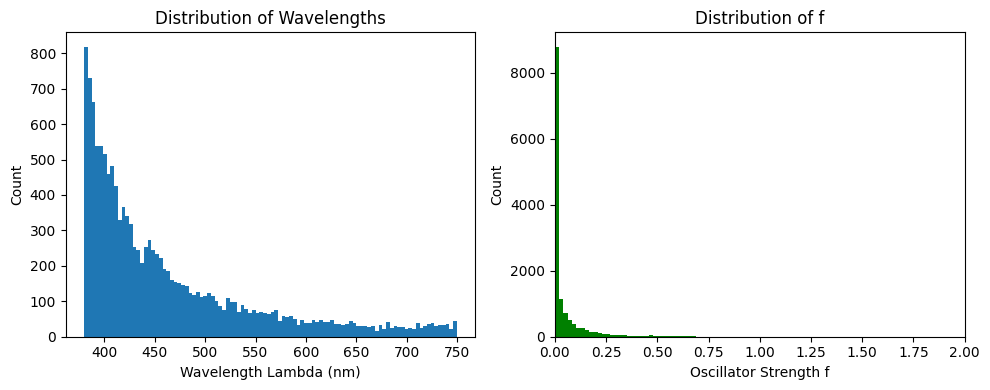

In [10]:
draw_outputs_distribution(f_values, lambdas)

As observed, the distribution for the Wavelength is heavily concentrated at values below $400$ nm, after which it decreases exponentially. While the maximum oscillator strength can theoretically occur across the entire visible spectrum range, it is most likely to occur at lower wavelength values.

Regarding the Oscillator Strength ($f$), the vast majority of values are close to zero (over $8,000$ instances). Conversely, for oscillator strengths greater than $0.02$, the frequency drops to only a few hundred cases, which is a relatively small number. This distribution indicates that the dataset is heavily biased towards the non-occurrence of significant oscillations. Consequently, the predictive model will likely have a tendency to omit or underestimate the impact of molecules exhibiting non-zero oscillator strengths.

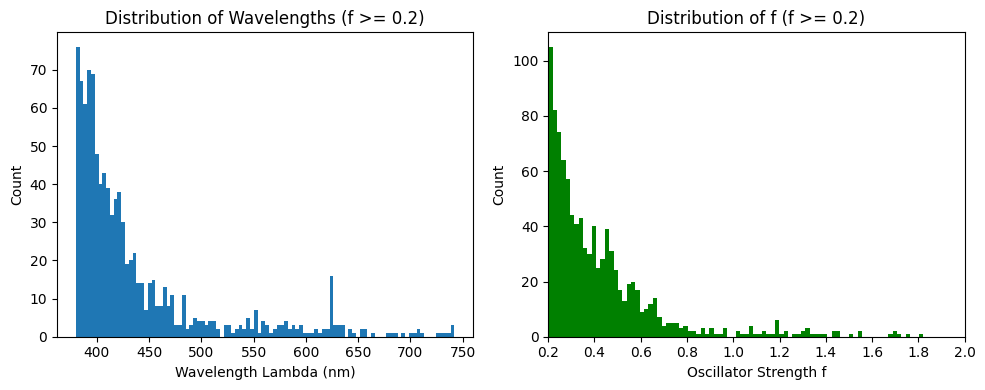

In [11]:
draw_outputs_distribution_filtered(f_values, lambdas)

If we filter the distribution to include only records where the oscillator strength ($f$) is $\mathbf{\ge 0.2}$, we observe an even stronger indication that these significant transitions occur predominantly below $450\text{ nm}$

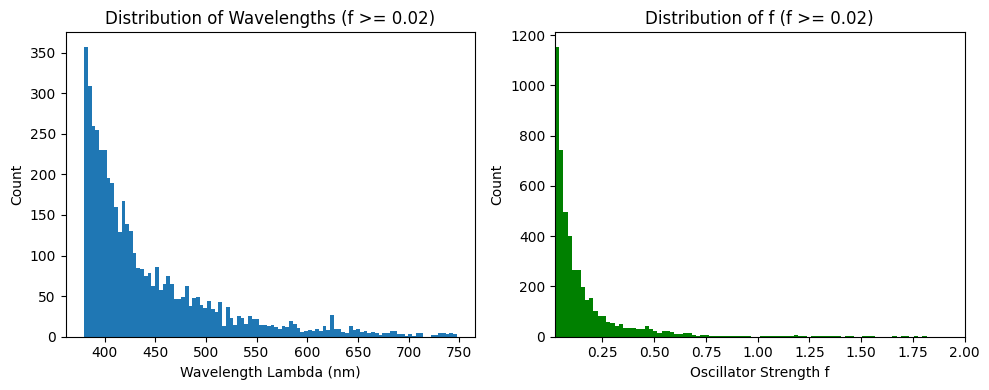

In [13]:
draw_outputs_distribution_filtered(f_values, lambdas, min_f_values=0.02)

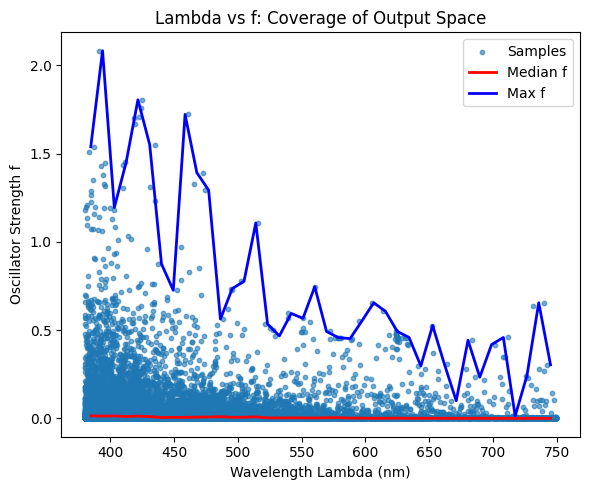

In [14]:
draw_space_covering(f_values, lambdas)

The plot illustrating the relationship between the Maximum Oscillator Strength ($f_{max}$) and the Wavelength ($\lambda$) clearly demonstrates a correlation between shorter wavelengths and higher oscillator strength values. This observation leads to an important modeling hypothesis: Would the overall prediction performance improve if the model were first trained to predict $f_{max}$ (or a relevant threshold), and then use that predicted value as an additional feature to determine the corresponding $\lambda$? This approach would effectively leverage the identified correlation and introduce a two-stage, or cascaded, prediction process.

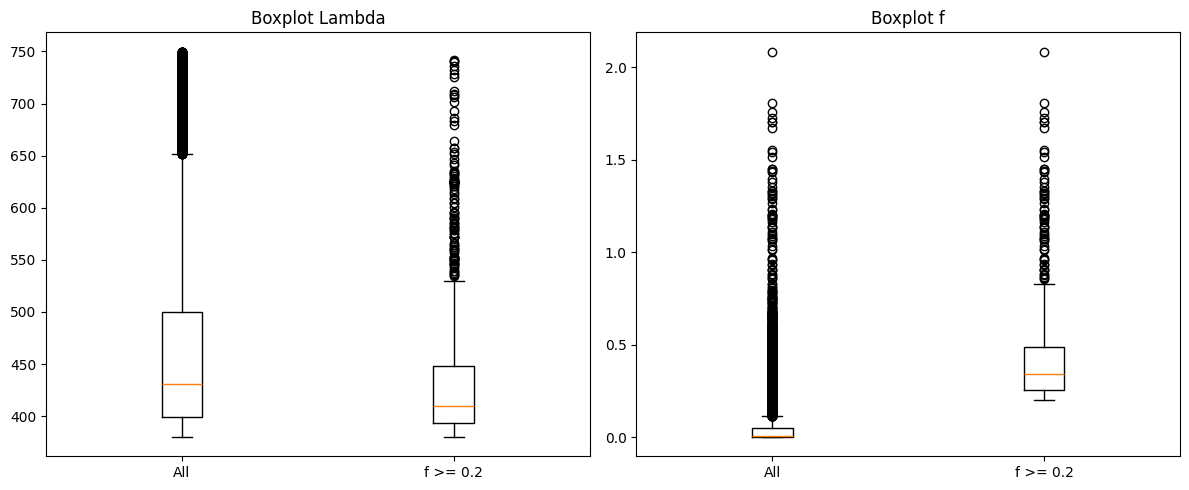

In [15]:
draw_boxplots(f_values, lambdas)

The diagram above visually confirms the previously described relationship: applying a filter for high maximum oscillator strength ($f_{max} \ge 0.2$) significantly reduces and shifts the dominant range of the corresponding wavelengths. 

- Wavelength ($\lambda$) Range (All Data): Most values fall within the $\mathbf{400-500 \text{ nm}}$ range. 

- Wavelength ($\lambda$) Range: (Filtered $f_{max} \ge 0.2$): The dominant range narrows to $\mathbf{400-450 \text{ nm}}$. 

An interesting observation is also made regarding the distribution of the $\mathbf{f \text{ values}}$ 

- $F$ Values (All Data): The majority of values are concentrated in the $\mathbf{0-0.02}$ range. 

- $F$ Values (Filtered $f_{max} \ge 0.2$): The distribution shifts to a much wider range, predominantly between $\mathbf{0.2-0.5}$ nm.

## High level analysis for output pairs (four pairs)


In [16]:
pair_config['additional_loading_params']['num_states'] = 4
print(pair_config)

four_pair_dataset = get_dataset_for(pair_config)

{'name': 'TMQM_SPECTO', 'root_dir': 'data/datasets/TMQM_SPECTO', 'pre_transforms': {}, 'transforms': {'AddEdgesAndDistances': {'cutoff': 5.0}}, 'in_channels': 1, 'out_channels': 8, 'task_type': 'multiregression', 'split_ratios': [0.8, 0.1], 'metric_mode': 'min', 'main_metric': 'MAE', 'additional_loading_params': {'prediction_type': 'pairs', 'num_states': 4, 'vis_range': [380, 750], 'block_3_only': True, 'filter_type': 'all_visible_lambdas', 'min_f_value': -1, 'sort_by_max_f': True, 'standarize_lambda': True, 'standarize_f': True}}
Loading dataset 'TMQM_SPECTO' from data/datasets/TMQM_SPECTO...
{'prediction_type': 'pairs', 'num_states': 4, 'vis_range': [380, 750], 'block_3_only': True, 'filter_type': 'all_visible_lambdas', 'min_f_value': -1, 'sort_by_max_f': True, 'standarize_lambda': True, 'standarize_f': True}


In [17]:
pyg_dataset_info(four_pair_dataset)

Number of graphs: 8874
Average nodes: 61.80
Average edges: 1586.00

Fields and shapes (first few samples):

Fields and example values:
  - y: ['Tensor(1, 8)', 'Tensor(1, 8)', 'Tensor(1, 8)']
  - pos: ['Tensor(81, 3)', 'Tensor(59, 3)', 'Tensor(69, 3)']
  - z: ['Tensor(81,)', 'Tensor(59,)', 'Tensor(69,)']
  - smiles: ['CC1=N(C(C)C)->[Sc+]23456(<-N=C(C(=N->2)c2ccccc2)c2ccccc2)(<-[N-]1C(C)C)<-c1(C)c->3(C)c->4(C)[c-]->5(C)c->61C', 'CCCN1C=CN(CCC)[C]1->[Ti+4](<-[Cl-])(<-[Cl-])(<-[Cl-])(<-[Cl-])<-[C]1N(CCC)C=CN1CCC', 'CC(C)(C)P1(Oc2cccc3OP(C(C)(C)C)(C(C)(C)C)->[Ti+4]<-1(<-[Cl-])(<-[Cl-])(<-[Cl-])<-[c-]23)C(C)(C)C']
  - origin_id: ['MIKLEB', 'HACSIR', 'HESBAM']
  - CSD_code: ['MIKLEB', 'HACSIR', 'HESBAM']
  - edge_index: ['Tensor(2, 2346)', 'Tensor(2, 1278)', 'Tensor(2, 1876)']
  - edge_weight: ['Tensor(2346,)', 'Tensor(1278,)', 'Tensor(1876,)']


In [18]:
four_pair_train_ds, four_pair_val_ds, four_pair_test_ds = split_dataset(four_pair_dataset, pair_config['split_ratios'])

In [19]:
def get_outputs_distribution_array(train_dataset, num_states=4):
    f_values_list = []
    lambda_list = []

    for data in train_dataset:
        y = data.y.squeeze()
        if y.numel() != num_states * 2:
            continue

        pairs = y.reshape(-1, 2).cpu().numpy()  
        lambda_list.append(pairs[:, 0])  
        f_values_list.append(pairs[:, 1])

    lambda_array = np.array(lambda_list).T  
    f_values_array = np.array(f_values_list).T 

    return f_values_array, lambda_array

In [20]:
four_f_values, four_lambdas = get_outputs_distribution_array(four_pair_train_ds, num_states=pair_config['additional_loading_params']['num_states'])

For 1 F


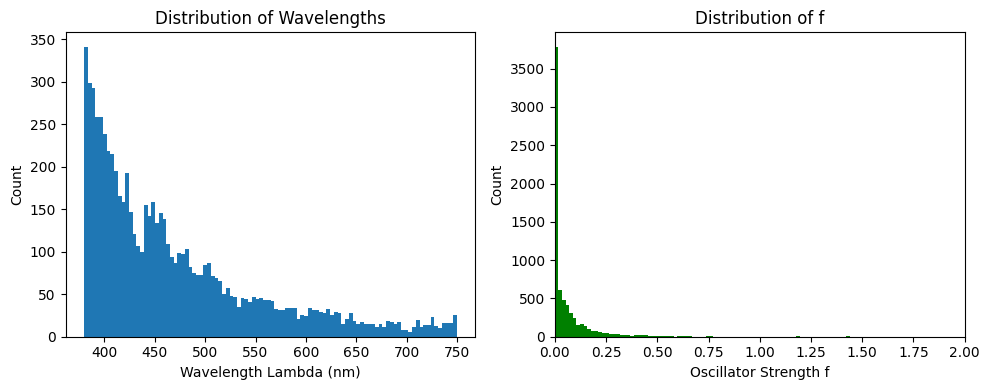

For 2 F


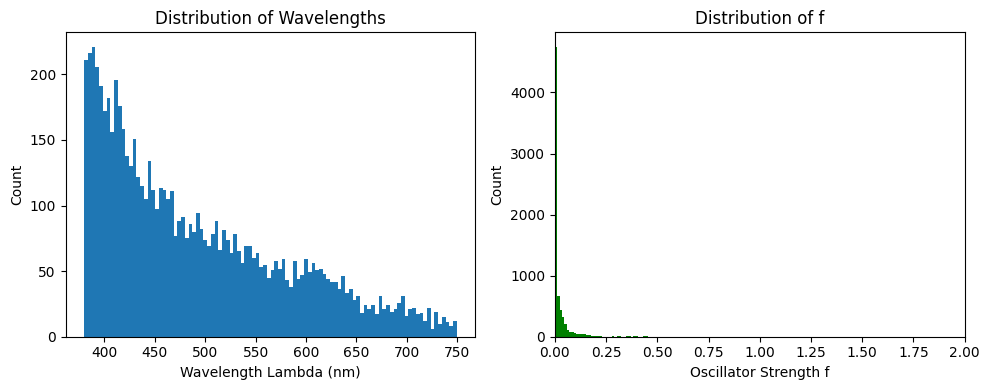

For 3 F


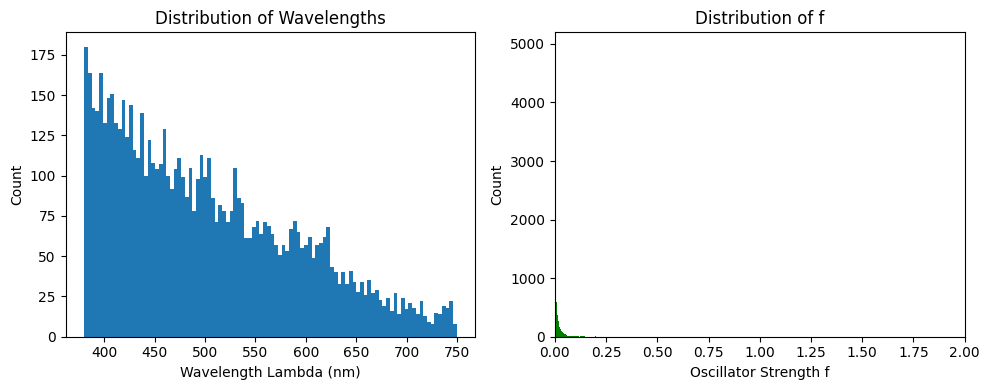

For 4 F


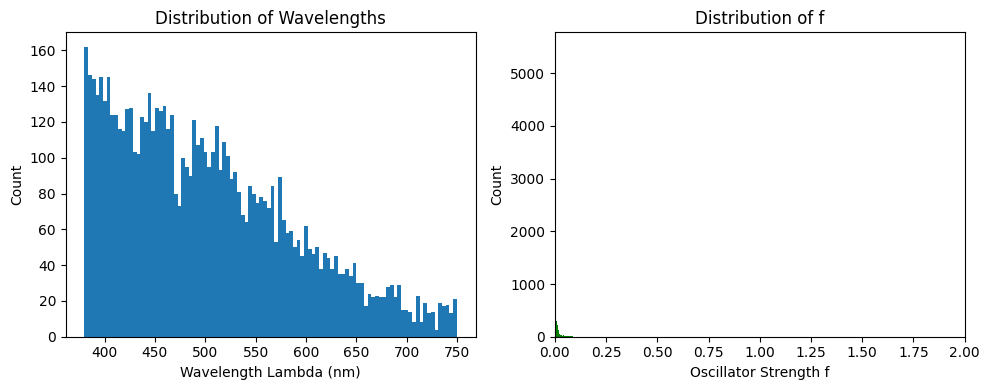

In [21]:
for i, (f_val, wavelenght) in enumerate(zip(four_f_values, four_lambdas)):
    print(f'For {i+1} F')
    draw_outputs_distribution(f_val, wavelenght)

As we consider increasing thresholds for $f_{max}$, we observe a corresponding decreasing count of non-zero oscillator strength ($f$) values across the dataset. Concurrently, the wavelength ($\lambda$) distribution becomes less exponentially skewed. Specifically, the count of records for small wavelengths ($\lambda$) decreases significantly, while the count for the highest wavelengths remains almost constant. This phenomenon confirms that high oscillator strength transitions are heavily concentrated in the lower (higher energy) end of the spectrum.""This leads to an important observation: Only a small fraction of molecules exhibits more than four $f$ values that are greater than or close to zero. This suggests that for most molecules, only a few electronic transitions are significant, reinforcing the sparsity of the target variable information.

For 1 F


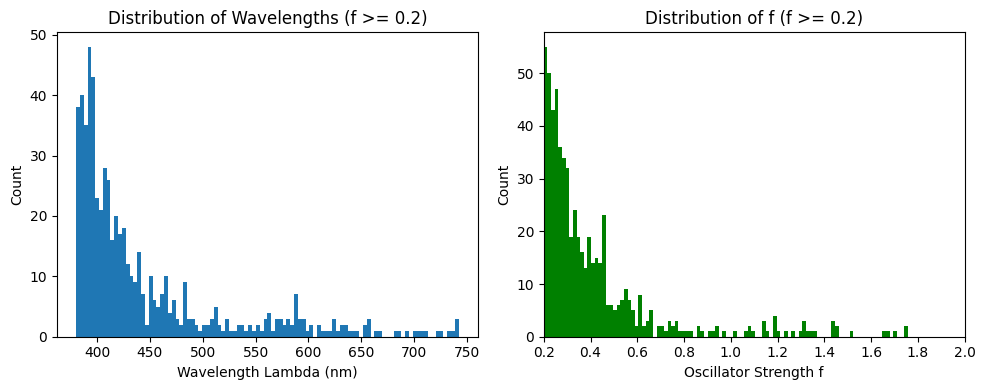

For 2 F


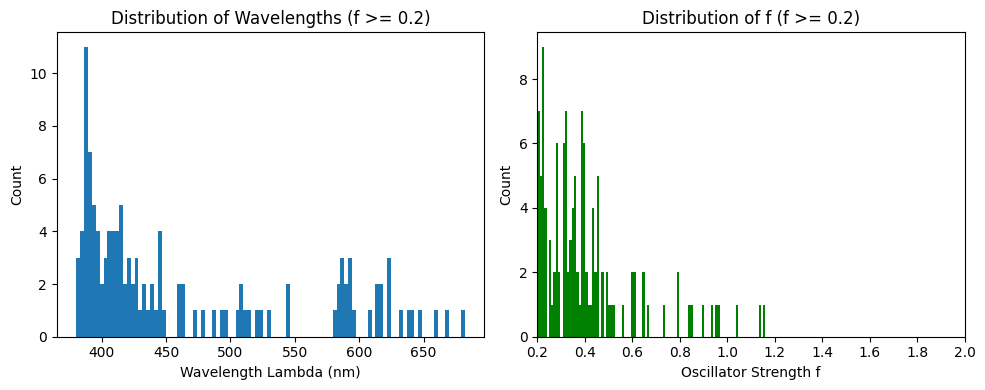

For 3 F


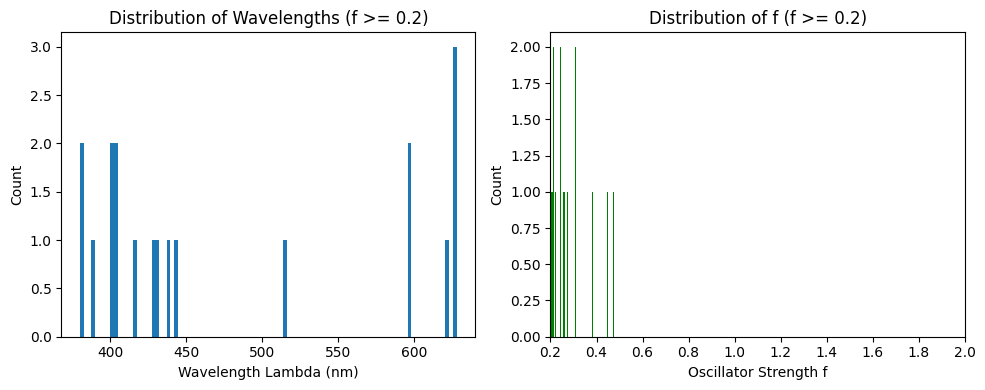

For 4 F


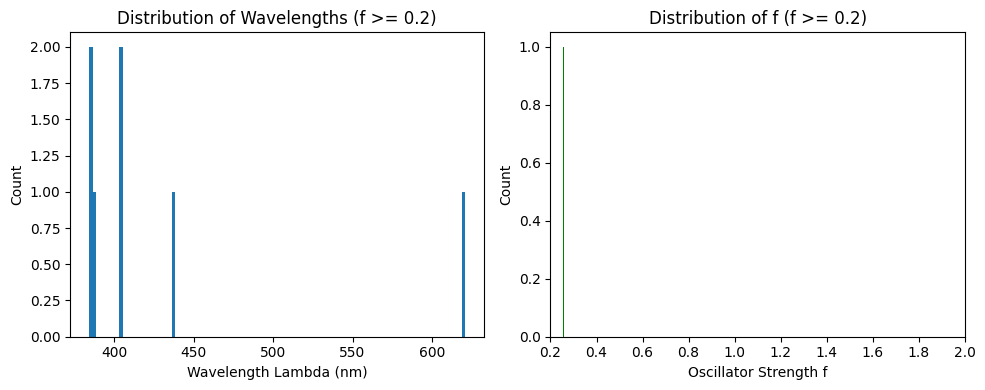

In [22]:
for i, (f_val, wavelenght) in enumerate(zip(four_f_values, four_lambdas)):
    print(f'For {i+1} F')
    draw_outputs_distribution_filtered(f_val, wavelenght)

The preceding observation regarding the decreasing count of non-zero $f$ values becomes even more pronounced when we exclusively consider oscillator strengths that meet the high-threshold condition of $\mathbf{f_i \ge 0.2}$. Under this strict filter, we find that only a few molecules possess a fourth significant $f$ value meeting this condition, and even the count for the third significant $f$ value is extremely low. This phenomenon is a direct result of data sparsity. 

Consequently, predicting the subsequent $f$ values (the third, fourth, and onward) that are $\ge 0.2$ will be significantly challenging for any model due to the severely limited number of samples available for these high-order transitions.

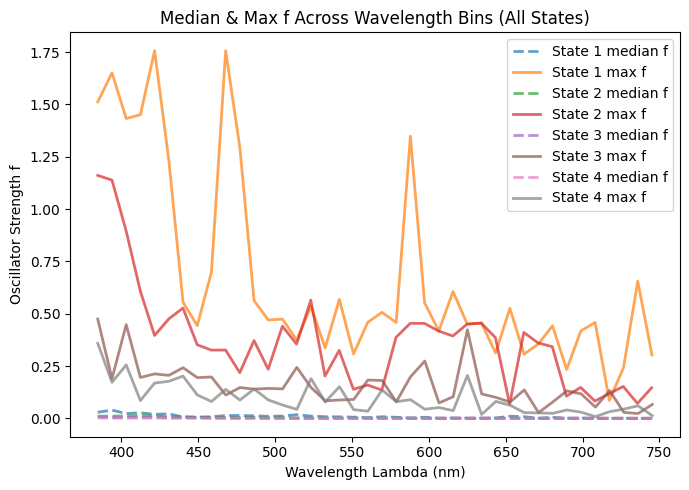

In [23]:
def draw_space_covering_states(f_array, lambda_array, bins=40):
    num_states = f_array.shape[0]

    plt.figure(figsize=(7, 5))

    for state in range(num_states):
        f_vals = f_array[state]
        lam_vals = lambda_array[state]

        bin_edges = np.linspace(lam_vals.min(), lam_vals.max(), bins + 1)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        median_f = []
        max_f = []

        for i in range(bins):
            mask = (lam_vals >= bin_edges[i]) & (lam_vals < bin_edges[i + 1])
            if np.any(mask):
                median_f.append(np.median(f_vals[mask]))
                max_f.append(np.max(f_vals[mask]))
            else:
                median_f.append(np.nan)
                max_f.append(np.nan)

        plt.plot(
            bin_centers,
            median_f,
            linewidth=2,
            alpha=0.7,
            linestyle="--",
            label=f"State {state+1} median f"
        )
        plt.plot(
            bin_centers,
            max_f,
            linewidth=2,
            alpha=0.7,
            label=f"State {state+1} max f"
        )

    plt.xlabel("Wavelength Lambda (nm)")
    plt.ylabel("Oscillator Strength f")
    plt.title("Median & Max f Across Wavelength Bins (All States)")
    plt.legend()
    plt.tight_layout()
    plt.show()

draw_space_covering_states(four_f_values, four_lambdas)



For the higher-order oscillator strengths (where $i \ge 2$, meaning the third, fourth, etc., transition), the relationship between $f_i$ and Wavelength ($\lambda$) is significantly more linear. The maximum $f_i$ values observed within each wavelength 'bucket' become similar across the spectrum. 

This contrasts sharply with the first two oscillator strengths ($f_0$ and $f_1$), where the negative correlation between $\lambda$ and $f_i$ is much more observable and pronounced.

Modeling Note: This difference suggests that the previously proposed approach of predicting $f$ and then using that prediction to determine its corresponding wavelength ($\lambda$) should not be as effective for predicting the higher-order transitions ($f_i$ where $i \ge 2$). For these transitions, the relationship is weaker, meaning $f_i$ offers little predictive power over $\lambda$.

## Graph properties analysis for output

Now we will focus on analysing the graph properties and what is their influence on results. First we focus on node features:

In [24]:
four_pair_train_ds[0]

Data(y=[1, 8], pos=[55, 3], z=[55], smiles='CSC1N=N2C=C3C=Cc4ccccc4[N-]3->[Zn+2]<-234(<-S=1)<-S=C(N=N->3C=C1C=Cc2ccccc2[N-]->41)SC', origin_id='GITCOF', CSD_code='GITCOF', edge_index=[2, 1056], edge_weight=[1056])

In [25]:
def analyze_node_features(dataset):
    all_atom_types = []
    pos_ranges = {"x": [], "y": [], "z": []}
    dist_stats = {"min": [], "max": [], "mean": [], "median": []}

    for data in dataset:
        z = data.z.cpu().numpy()
        all_atom_types.extend(z.tolist())

        pos = data.pos.cpu().numpy()  
        pos_ranges["x"].append((pos[:, 0].min(), pos[:, 0].max()))
        pos_ranges["y"].append((pos[:, 1].min(), pos[:, 1].max()))
        pos_ranges["z"].append((pos[:, 2].min(), pos[:, 2].max()))

        if pos.shape[0] > 1:
            d = np.linalg.norm(
                pos[:, None, :] - pos[None, :, :], axis=-1
            )
            d = d[np.triu_indices_from(d, k=1)]  

            dist_stats["min"].append(np.min(d))
            dist_stats["max"].append(np.max(d))
            dist_stats["mean"].append(np.mean(d))
            dist_stats["median"].append(np.median(d))

    atom_type_counter = Counter(all_atom_types)

    summary = {
        "atom_type_distribution": dict(atom_type_counter),
        "num_unique_atom_types": len(atom_type_counter),
        "pos_coordinate_global_range": {
            "x_min": min(x[0] for x in pos_ranges["x"]),
            "x_max": max(x[1] for x in pos_ranges["x"]),
            "y_min": min(y[0] for y in pos_ranges["y"]),
            "y_max": max(y[1] for y in pos_ranges["y"]),
            "z_min": min(z[0] for z in pos_ranges["z"]),
            "z_max": max(z[1] for z in pos_ranges["z"]),
        },
        "distance_statistics": {
            "min_distance_mean": np.mean(dist_stats["min"]),
            "min_distance_min": np.min(dist_stats["min"]),
            "min_distance_max": np.max(dist_stats["min"]),

            "max_distance_mean": np.mean(dist_stats["max"]),
            "max_distance_min": np.min(dist_stats["max"]),
            "max_distance_max": np.max(dist_stats["max"]),

            "mean_distance_mean": np.mean(dist_stats["mean"]),
            "median_distance_mean": np.mean(dist_stats["median"]),
        },
    }

    return summary

def collect_node_and_output_correlations(dataset):
    rows = []

    for data in dataset:
        y = data.y.squeeze().cpu().numpy()

        if y.shape[0] != 8:
            continue

        pairs = y.reshape(-1, 2)
        lambdas = pairs[:, 0]
        fs = pairs[:, 1]

        pos = data.pos.cpu().numpy()
        z = data.z.cpu().numpy()
        N = pos.shape[0]

        atom_counts = np.bincount(z)
        atom_probs = atom_counts / atom_counts.sum()
        atom_entropy = entropy(atom_probs)

        std_x, std_y, std_z = pos[:,0].std(), pos[:,1].std(), pos[:,2].std()

        volume = (
            (pos[:,0].max() - pos[:,0].min()) *
            (pos[:,1].max() - pos[:,1].min()) *
            (pos[:,2].max() - pos[:,2].min())
        )

        if N > 1:
            d = np.linalg.norm(pos[:,None,:] - pos[None,:,:], axis=-1)
            d = d[np.triu_indices_from(d, k=1)]
            mean_dist = d.mean()
        else:
            mean_dist = np.nan

        com = pos.mean(axis=0)
        com_dist = np.linalg.norm(com)

        rows.append({
            "num_nodes": N,
            "atom_entropy": atom_entropy,
            "std_x": std_x,
            "std_y": std_y,
            "std_z": std_z,
            "bbox_volume": volume,
            "mean_pairwise_dist": mean_dist,
            "com_dist_origin": com_dist,

            "lambda1": lambdas[0],
            "lambda2": lambdas[1],
            "lambda3": lambdas[2],
            "lambda4": lambdas[3],

            "f1": fs[0],
            "f2": fs[1],
            "f3": fs[2],
            "f4": fs[3],
        })

    return pd.DataFrame(rows)

def plot_node_feature_correlations(df):
    df_clean = df.dropna(axis=1)

    corr_pearson = df_clean.corr(method="pearson")
    corr_spearman = df_clean.corr(method="spearman")

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_pearson, cmap="coolwarm", annot=True, fmt=".2f")
    plt.title("Pearson Correlation Heatmap: Node Features vs 4F & 4 Lambdas")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_spearman, cmap="viridis", annot=True, fmt=".2f")
    plt.title("Spearman Correlation Heatmap: Node Features vs 4F & 4 Lambdas")
    plt.tight_layout()
    plt.show()

    return corr_pearson, corr_spearman



In [26]:
analyze_node_features(four_pair_train_ds)

{'atom_type_distribution': {30: 130,
  16: 4019,
  7: 24284,
  6: 165209,
  1: 181013,
  28: 3112,
  8: 13947,
  9: 2537,
  27: 1569,
  5: 2985,
  15: 2597,
  29: 309,
  35: 1144,
  17: 2396,
  23: 191,
  26: 1329,
  22: 190,
  33: 49,
  25: 152,
  24: 117,
  34: 173,
  14: 250,
  21: 1},
 'num_unique_atom_types': 23,
 'pos_coordinate_global_range': {'x_min': np.float32(-20.937132),
  'x_max': np.float32(49.39644),
  'y_min': np.float32(-29.90942),
  'y_max': np.float32(56.84998),
  'z_min': np.float32(-45.64371),
  'z_max': np.float32(50.476326)},
 'distance_statistics': {'min_distance_mean': np.float32(1.0557795),
  'min_distance_min': np.float32(0.95479053),
  'min_distance_max': np.float32(1.1740353),
  'max_distance_mean': np.float32(12.665155),
  'max_distance_min': np.float32(5.359391),
  'max_distance_max': np.float32(35.09157),
  'mean_distance_mean': np.float32(5.6798687),
  'median_distance_mean': np.float32(5.577895)}}

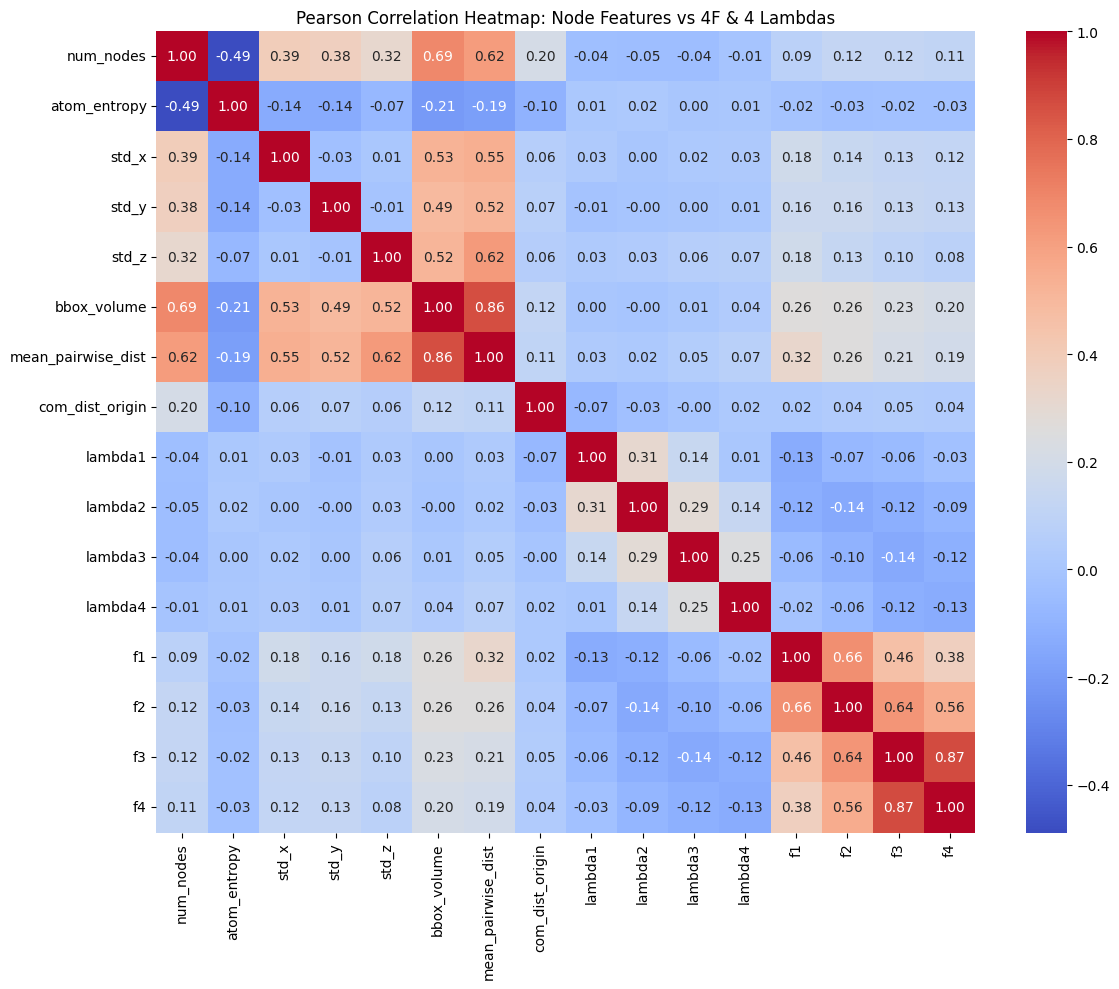

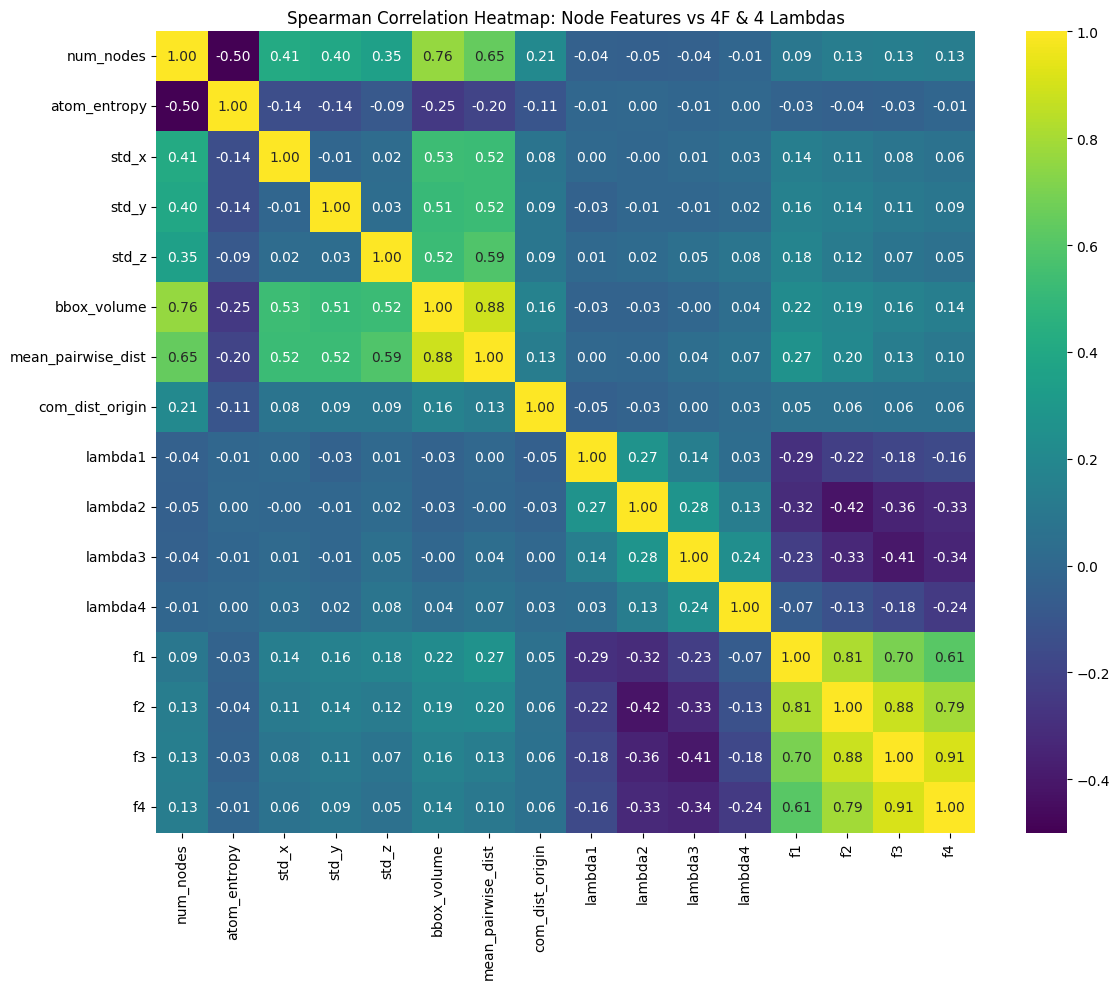

In [27]:
df_nodes = collect_node_and_output_correlations(four_pair_train_ds)
pearson, spearman = plot_node_feature_correlations(df_nodes)

The initial correlation analysis between the node features (e.g., coordinate statistics) and the target values ($f$ and $\lambda$) reveals a low correlation for both. This result was anticipated, as these features are generally less related to the specific electronic structure of the molecule and more related to global, non-structural properties. For instance, the standard deviation (STD) of coordinates captures overall coordinate spread, rather than the specific, local arrangement of atoms.

Nevertheless, two global features exhibit a noteworthy, albeit moderate, correlation: Bounding Box Volume ($\text{BBox Volume}$): The volume of the smallest axis-aligned box encompassing the molecule shows a correlation of approximately $\sim 0.3$ with the $f$ values. Mean Pairwise Distance ($\text{Mean Pairwise Dist}$): The average Euclidean distance between all atom pairs within the molecule shows a correlation of about $\sim 0.2$ with the $f$ values.These moderate correlations suggest that the overall molecular size and density are factors influencing the oscillator strength ($f$).

The high negative internal correlation between the Oscillator Strength ($f$) and Wavelength ($\lambda$) pairs remains the data's most prominent feature. This strong internal structure supports a sequential or joint prediction strategy. The recurrent model should be considered or a specialized multi-target model to exploit the dependence between the ordered $(f_i, \lambda_i)$ transitions, as this may yield more robust results than a simple feed-forward approach.

In [28]:
def collect_atom_counts_and_outputs(dataset):
    unique_z = set()
    for data in dataset:
        z = data.z.cpu().numpy().tolist()
        unique_z.update(z)

    unique_z = sorted(list(unique_z))  
    rows = []

    for data in dataset:
        y = data.y.squeeze().cpu().numpy()

        if y.shape[0] != 8:
            continue

        pairs = y.reshape(-1, 2)
        lambdas = pairs[:, 0]
        fs = pairs[:, 1]

        z = data.z.cpu().numpy().tolist()
        z_count = Counter(z)

        row = {}

        for Z in unique_z:
            row[f"atom_Z_{Z}"] = z_count.get(Z, 0)

        row.update({
            "lambda1": lambdas[0], "lambda2": lambdas[1],
            "lambda3": lambdas[2], "lambda4": lambdas[3],
            "f1": fs[0], "f2": fs[1], "f3": fs[2], "f4": fs[3],
        })

        rows.append(row)

    return pd.DataFrame(rows)


def plot_atom_count_correlations(df):
    df_clean = df.dropna()

    output_cols = ["lambda1", "lambda2", "lambda3", "lambda4",
                   "f1", "f2", "f3", "f4"]

    atom_cols = [c for c in df_clean.columns if c.startswith("atom_Z_")]

    corr_mat = pd.DataFrame(index=atom_cols, columns=output_cols)

    for atom in atom_cols:
        for out in output_cols:
            corr_mat.loc[atom, out] = df_clean[atom].corr(df_clean[out])

    plt.figure(figsize=(12, 6))
    sns.heatmap(corr_mat.astype(float), annot=True, fmt=".2f",
                cmap="coolwarm", linewidths=.5)
    plt.title("Correlation of Atom Counts with Lambdas and f")
    plt.xlabel("Outputs (Lambdas & f)")
    plt.ylabel("Atom Count Features")
    plt.tight_layout()
    plt.show()

    return corr_mat


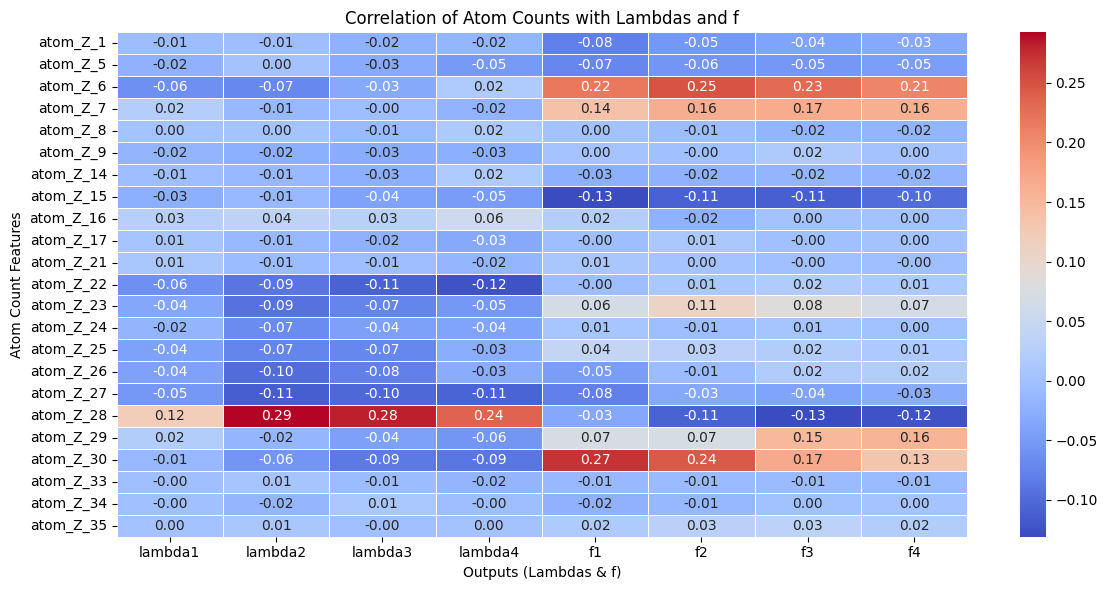

,lambda1,lambda2,lambda3,lambda4,f1,f2,f3,f4
atom_Z_1,-0.006406,-0.005131,-0.02117,-0.015308,-0.078976,-0.053431,-0.039615,-0.032348
atom_Z_5,-0.023042,0.002372,-0.031068,-0.051363,-0.071621,-0.055584,-0.054673,-0.045699
atom_Z_6,-0.063126,-0.070773,-0.03334,0.01682,0.219335,0.248777,0.231074,0.207342
atom_Z_7,0.023591,-0.010787,-0.004637,-0.019745,0.137086,0.164987,0.16652,0.161812
atom_Z_8,0.004037,0.003702,-0.008717,0.01591,0.002629,-0.006781,-0.018196,-0.018346
atom_Z_9,-0.017592,-0.024618,-0.028537,-0.026079,0.003515,-0.000729,0.015618,0.001351
atom_Z_14,-0.005249,-0.010774,-0.025595,0.017425,-0.02633,-0.020484,-0.018326,-0.018873
atom_Z_15,-0.025637,-0.011405,-0.040735,-0.049825,-0.130794,-0.110545,-0.11205,-0.098619
atom_Z_16,0.026656,0.035271,0.028095,0.057203,0.022885,-0.02125,0.001496,0.002207
atom_Z_17,0.005758,-0.011244,-0.021064,-0.032355,-0.004367,0.012079,-0.000431,0.001992


In [29]:
df_atoms = collect_atom_counts_and_outputs(four_pair_train_ds)
corr_atoms = plot_atom_count_correlations(df_atoms)
corr_atoms

The provided heatmap, which correlates the count of specific atom types within a molecule to the target variables ($f$ and $\lambda$), highlights a handful of atoms exhibiting a promising correlation: specifically, atoms 6, 7, 15, 28, and 30.It is, however, crucially important to interpret these correlations with caution due to the significant disparity in their representation within the dataset:

- Atom 6 about 164,686 times
- Atom 30 only 127 times

The correlation observed for frequently occurring atoms (like Atom 6) is likely reliable. Conversely, the strong signal from rare atoms (like Atom 30) must be viewed skeptically; their correlation might simply be an artifact of the few molecules in which they appear, rather than a generalizable structural principle. This observation is critical when designing features based on atomic composition.

In [30]:
def analyze_edge_structure(dataset):
    edge_counts = []
    avg_degrees = []
    max_degrees = []

    all_degrees = []
    all_edge_weights = []

    per_graph_stats = []

    for data in dataset:
        edge_index = data.edge_index.cpu().numpy()
        num_edges = edge_index.shape[1]
        edge_counts.append(num_edges)

        degrees = np.bincount(edge_index[0], minlength=data.num_nodes)
        deg_mean = degrees.mean()
        deg_max = degrees.max()

        avg_degrees.append(deg_mean)
        max_degrees.append(deg_max)
        all_degrees.extend(degrees.tolist())

        if hasattr(data, "edge_weight") and data.edge_weight is not None:
            ew = data.edge_weight.cpu().numpy()
            all_edge_weights.extend(ew.tolist())
            ew_min = ew.min()
            ew_max = ew.max()
            ew_mean = ew.mean()
        else:
            ew_min = ew_max = ew_mean = None

        per_graph_stats.append({
            "num_edges": num_edges,
            "mean_degree": deg_mean,
            "max_degree": deg_max,
            "edge_weight_min": ew_min,
            "edge_weight_max": ew_max,
            "edge_weight_mean": ew_mean,
        })

    summary = {
        "num_graphs": len(dataset),

        "edge_count": {
            "mean": np.mean(edge_counts),
            "min": np.min(edge_counts),
            "max": np.max(edge_counts),
            "median": np.median(edge_counts),
        },

        "degree": {
            "global_mean_degree": np.mean(all_degrees),
            "global_max_degree": np.max(all_degrees),
            "degree_distribution": dict(Counter(all_degrees)),
        },

        "avg_degree_per_graph": {
            "mean": np.mean(avg_degrees),
            "min": np.min(avg_degrees),
            "max": np.max(avg_degrees),
        },

        "max_degree_per_graph": {
            "mean": np.mean(max_degrees),
            "min": np.min(max_degrees),
            "max": np.max(max_degrees),
        },

        "edge_weight": (
            {
                "min": float(np.min(all_edge_weights)),
                "max": float(np.max(all_edge_weights)),
                "mean": float(np.mean(all_edge_weights)),
                "median": float(np.median(all_edge_weights)),
            }
            if len(all_edge_weights) > 0 else None
        )
    }

    return summary, per_graph_stats


In [31]:
edge_summary, per_graph_stats = analyze_edge_structure(four_pair_train_ds)

In [32]:
edge_summary

{'num_graphs': 7100,
 'edge_count': {'mean': np.float64(1379.3947887323943),
  'min': np.int64(148),
  'max': np.int64(2941),
  'median': np.float64(1334.0)},
 'degree': {'global_mean_degree': np.float64(24.02166037532223),
  'global_max_degree': np.int64(75),
  'degree_distribution': {33: 9619,
   25: 16504,
   11: 9528,
   26: 16559,
   32: 10609,
   23: 16823,
   29: 14722,
   20: 17905,
   28: 15713,
   27: 16224,
   21: 17976,
   18: 16121,
   19: 17367,
   13: 12197,
   15: 14716,
   10: 7172,
   6: 88,
   7: 238,
   14: 13510,
   31: 11343,
   17: 16954,
   24: 16762,
   22: 18145,
   12: 11493,
   8: 776,
   16: 15605,
   9: 2093,
   35: 7370,
   30: 12951,
   36: 6700,
   37: 5777,
   39: 4100,
   38: 5013,
   41: 2981,
   40: 3564,
   48: 841,
   60: 51,
   44: 1839,
   42: 2409,
   46: 1287,
   45: 1337,
   43: 1980,
   34: 8777,
   58: 70,
   54: 203,
   52: 379,
   50: 550,
   47: 893,
   49: 664,
   51: 396,
   53: 269,
   57: 98,
   56: 128,
   55: 122,
   68: 1,
   66: 

In [33]:
def collect_edge_and_output_stats(dataset):
    stats = []

    for data in dataset:
        if data.edge_index is None:
            continue

        edge_index = data.edge_index.cpu().numpy()
        num_edges = edge_index.shape[1]

        degrees = np.bincount(edge_index[0], minlength=data.num_nodes)
        mean_deg = degrees.mean()
        max_deg = degrees.max()

        if hasattr(data, "edge_weight") and data.edge_weight is not None:
            ew = data.edge_weight.cpu().numpy()
            ew_mean = ew.mean()
            ew_max = ew.max()
        else:
            ew_mean = np.nan
            ew_max = np.nan

        y = data.y.squeeze().cpu().numpy()
        if y.size % 2 != 0:
            continue

        pairs = y.reshape(-1, 2)
        lambdas = pairs[:, 0]
        f_vals  = pairs[:, 1]

        f_max = np.max(f_vals)
        lambda_mean = np.mean(lambdas)

        stats.append({
            "num_edges": num_edges,
            "mean_degree": mean_deg,
            "max_degree": max_deg,
            "mean_edge_weight": ew_mean,
            "max_edge_weight": ew_max,
            "f_max": f_max,
            "lambda_mean": lambda_mean
        })

    return stats


def plot_edge_structure_histograms(stats):
    num_edges      = [s["num_edges"] for s in stats]
    mean_deg       = [s["mean_degree"] for s in stats]
    max_deg        = [s["max_degree"] for s in stats]
    mean_edge_w    = [s["mean_edge_weight"] for s in stats if not np.isnan(s["mean_edge_weight"])]
    max_edge_w     = [s["max_edge_weight"] for s in stats if not np.isnan(s["max_edge_weight"])]

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.hist(num_edges, bins=50)
    plt.xlabel("Number of edges")
    plt.title("Edge count distribution")

    plt.subplot(2, 2, 2)
    plt.hist(mean_deg, bins=50)
    plt.xlabel("Mean degree")
    plt.title("Mean node degree distribution")

    plt.subplot(2, 2, 3)
    plt.hist(max_deg, bins=50)
    plt.xlabel("Max degree")
    plt.title("Maximum degree distribution")

    plt.subplot(2, 2, 4)
    plt.hist(mean_edge_w, bins=50)
    plt.xlabel("Mean edge weight")
    plt.title("Mean edge-weight distribution")

    plt.tight_layout()
    plt.show()

def plot_edge_vs_output(stats):
    num_edges   = np.array([s["num_edges"] for s in stats])
    mean_deg    = np.array([s["mean_degree"] for s in stats])
    max_deg     = np.array([s["max_degree"] for s in stats])
    f_max       = np.array([s["f_max"] for s in stats])
    lambda_mean = np.array([s["lambda_mean"] for s in stats])

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.scatter(num_edges, f_max, alpha=0.5)
    plt.xlabel("Number of edges")
    plt.ylabel("f_max")

    plt.subplot(2, 2, 2)
    plt.scatter(mean_deg, f_max, alpha=0.5)
    plt.xlabel("Mean degree")
    plt.ylabel("f_max")

    plt.tight_layout()
    plt.show()


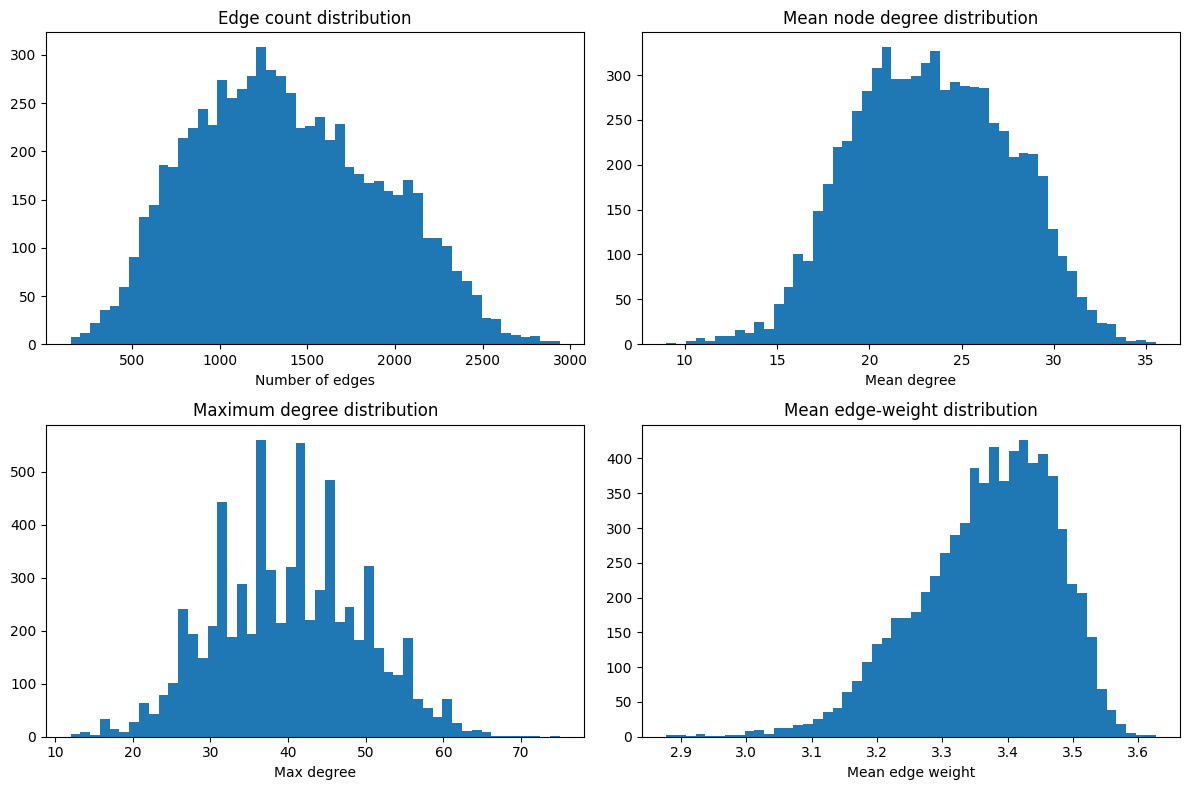

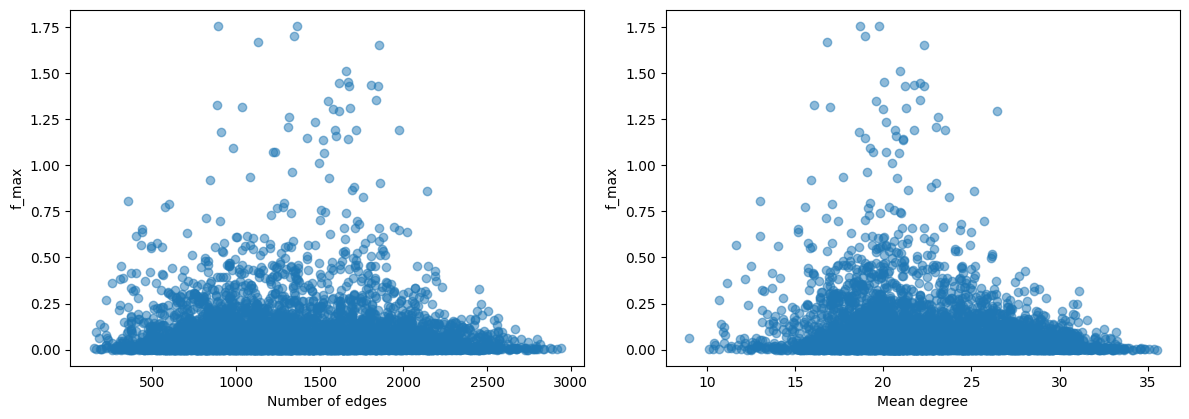

In [34]:
stats = collect_edge_and_output_stats(four_pair_train_ds)

plot_edge_structure_histograms(stats)
plot_edge_vs_output(stats)



In [35]:
def collect_edge_and_output_stats_4f(dataset):
    stats = []

    for data in dataset:
        edge_index = data.edge_index.cpu().numpy()
        num_edges = edge_index.shape[1]

        degrees = np.bincount(edge_index[0], minlength=data.num_nodes)
        mean_degree = degrees.mean()
        max_degree = degrees.max()

        if hasattr(data, "edge_weight") and data.edge_weight is not None:
            ew = data.edge_weight.cpu().numpy()
            mean_edge_weight = ew.mean()
            max_edge_weight = ew.max()
        else:
            mean_edge_weight = None
            max_edge_weight = None

        y = data.y.squeeze().cpu().numpy()
        if y.shape[0] != 8:
            continue  

        pairs = y.reshape(-1, 2)  

        lambdas = pairs[:, 0]
        fs = pairs[:, 1]

        stats.append({
            "num_edges": num_edges,
            "mean_degree": mean_degree,
            "max_degree": max_degree,
            "mean_edge_weight": mean_edge_weight,
            "max_edge_weight": max_edge_weight,

            "f1": fs[0],
            "f2": fs[1],
            "f3": fs[2],
            "f4": fs[3],

            "lambda1": lambdas[0],
            "lambda2": lambdas[1],
            "lambda3": lambdas[2],
            "lambda4": lambdas[3],
        })

    return pd.DataFrame(stats)

def plot_correlation_heatmaps_4f(df):
    df = df.dropna(axis=1)

    cols = [
        "num_edges", "mean_degree", "max_degree",
        "mean_edge_weight", "max_edge_weight",
        "f1", "f2", "f3", "f4",
        "lambda1", "lambda2", "lambda3", "lambda4"
    ]
    cols = [c for c in cols if c in df.columns]

    pearson = df[cols].corr(method="pearson")
    spearman = df[cols].corr(method="spearman")

    plt.figure(figsize=(12, 10))
    sns.heatmap(pearson, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Pearson Correlation Heatmap (Graph Structure vs 4F Outputs)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 10))
    sns.heatmap(spearman, annot=True, cmap="viridis", fmt=".2f")
    plt.title("Spearman Correlation Heatmap (Graph Structure vs 4F Outputs)")
    plt.tight_layout()
    plt.show()

    return pearson, spearman




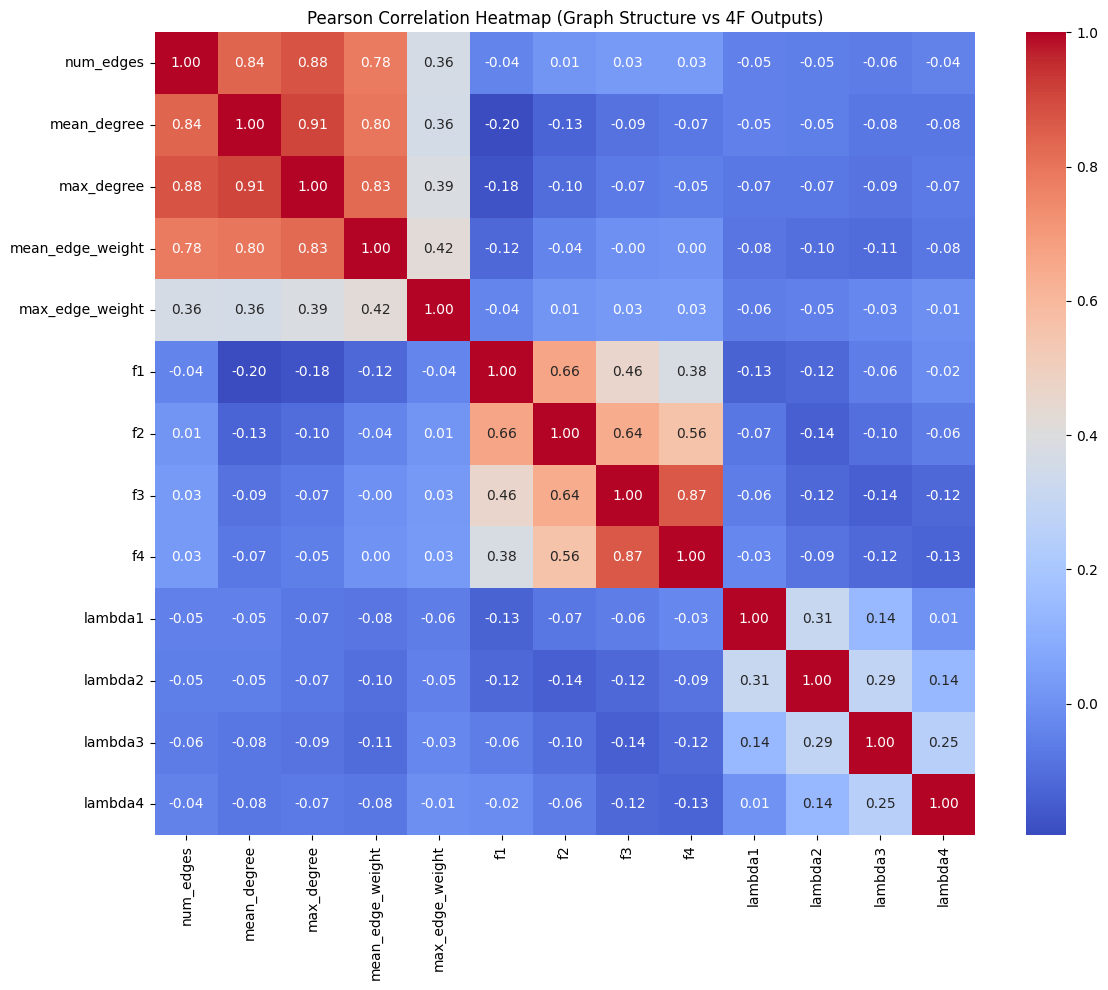

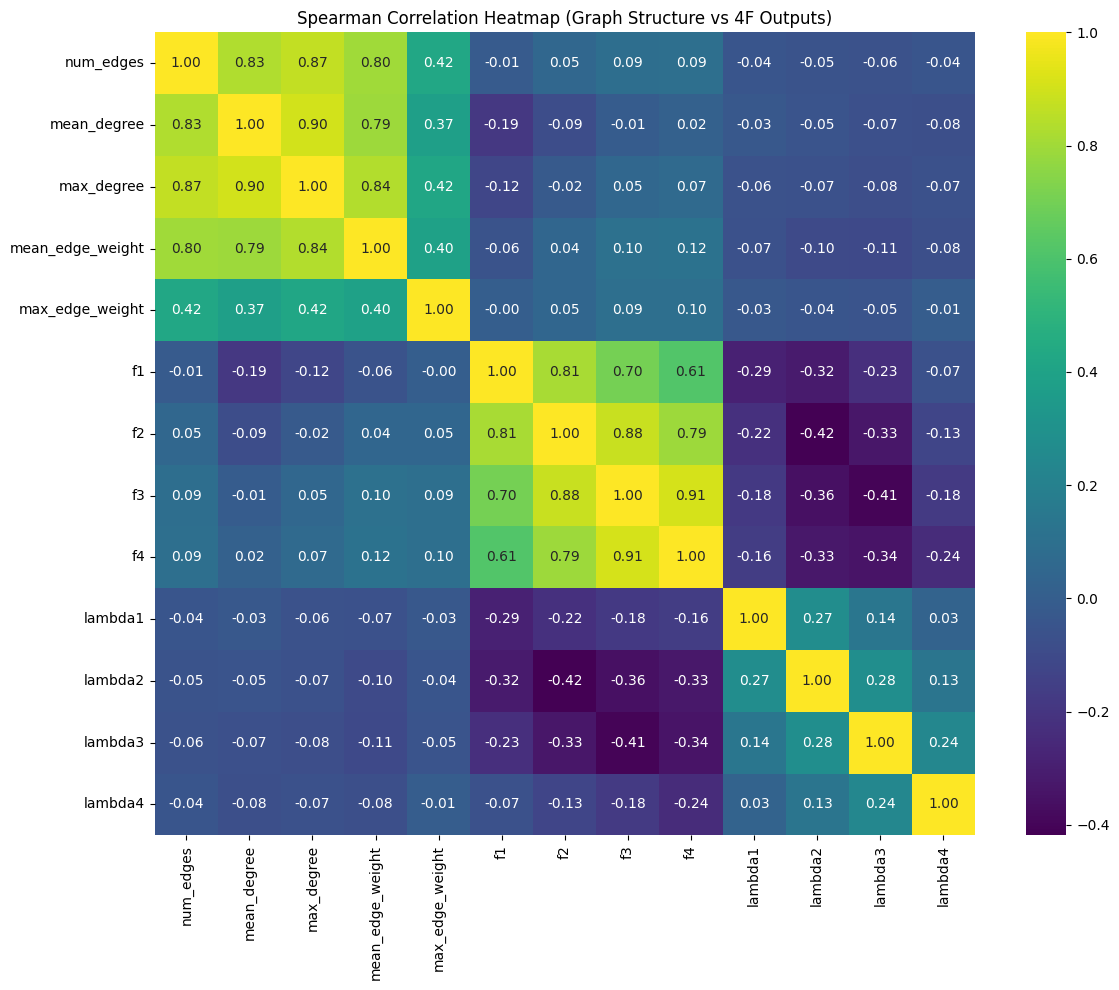

In [36]:
df_stats = collect_edge_and_output_stats_4f(four_pair_train_ds)
pearson_corr, spearman_corr = plot_correlation_heatmaps_4f(df_stats)

The analysis of pure edge features (e.g., edge count, edge type distribution) reveals that they do not exhibit many interesting correlations with the target variables ($f$ and $\lambda$). Only the relationship with the Mean Degree (and similarly, the Maximum Degree) shows a measurable impact. However, this impact becomes less and less significant as we consider the higher-order oscillator strengths ($f_i$) and their corresponding wavelengths ($\lambda_i$). This suggests that while basic graph connectivity metrics might weakly influence the primary transitions, they quickly lose predictive power for the more subtle, higher-energy transitions.

In [37]:
def collect_graph_structure_and_outputs(dataset):
    rows = []

    for data in dataset:
        y = data.y.squeeze().cpu().numpy()
        if y.shape[0] != 8:
            continue

        pairs = y.reshape(-1, 2)
        lambdas = pairs[:, 0]
        fs = pairs[:, 1]

        edge_index = data.edge_index.cpu().numpy()
        edge_weight = data.edge_weight.cpu().numpy() if hasattr(data, "edge_weight") else None
        N = data.num_nodes
        E = edge_index.shape[1]

        deg = np.bincount(edge_index[0], minlength=N)

        density = E / (N * N)

        if edge_weight is not None and len(edge_weight) > 0:
            avg_w = edge_weight.mean()
            max_w = edge_weight.max()
            min_w = edge_weight.min()
            std_w = edge_weight.std()
        else:
            avg_w = max_w = min_w = std_w = np.nan

        rows.append({
            "num_nodes": N,
            "num_edges": E,
            "density": density,
            "avg_degree": deg.mean(),
            "max_degree": deg.max(),
            "min_degree": deg.min(),
            "std_degree": deg.std(),
            "avg_edge_weight": avg_w,
            "max_edge_weight": max_w,
            "min_edge_weight": min_w,
            "std_edge_weight": std_w,

            "lambda1": lambdas[0],
            "lambda2": lambdas[1],
            "lambda3": lambdas[2],
            "lambda4": lambdas[3],

            "f1": fs[0],
            "f2": fs[1],
            "f3": fs[2],
            "f4": fs[3],
        })

    return pd.DataFrame(rows)

def plot_graph_feature_to_output_correlations(df):
    df_clean = df.dropna()

    output_cols = ["lambda1", "lambda2", "lambda3", "lambda4",
                   "f1", "f2", "f3", "f4"]

    feature_cols = [c for c in df_clean.columns if c not in output_cols]

    corr_matrix = pd.DataFrame(
        index=feature_cols,
        columns=output_cols,
        dtype=float
    )

    for feat in feature_cols:
        for out in output_cols:
            corr_matrix.loc[feat, out] = df_clean[feat].corr(df_clean[out])

    plt.figure(figsize=(12, 6))
    sns.heatmap(corr_matrix.astype(float), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation: Graph Structural Features - Lambdas and F")
    plt.xlabel("Outputs (Lambdas & f)")
    plt.ylabel("Graph Structural Features")
    plt.tight_layout()
    plt.show()

    return corr_matrix

In [38]:
df_graph = collect_graph_structure_and_outputs(four_pair_train_ds)


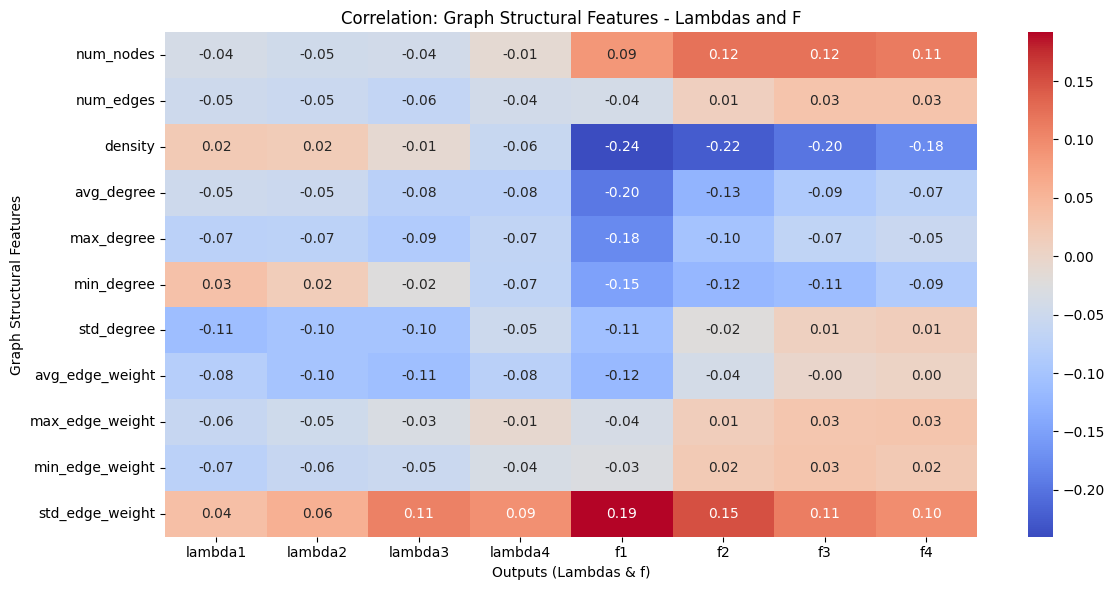

,lambda1,lambda2,lambda3,lambda4,f1,f2,f3,f4
num_nodes,-0.039196,-0.045359,-0.042802,-0.010845,0.085654,0.122242,0.122488,0.112742
num_edges,-0.048048,-0.053909,-0.064218,-0.043834,-0.040890,0.010661,0.030389,0.031389
density,0.020243,0.016432,-0.009727,-0.057345,-0.240116,-0.223351,-0.198182,-0.175528
avg_degree,-0.048587,-0.051772,-0.075459,-0.075063,-0.195906,-0.126964,-0.089024,-0.071930
max_degree,-0.073939,-0.072831,-0.086781,-0.066085,-0.176183,-0.103052,-0.066934,-0.054618
min_degree,0.033257,0.016087,-0.024150,-0.067255,-0.149844,-0.121620,-0.112088,-0.087443
std_degree,-0.111477,-0.101136,-0.100306,-0.050383,-0.107332,-0.021509,0.008429,0.013779
avg_edge_weight,-0.080311,-0.100333,-0.110037,-0.075939,-0.118594,-0.040244,-0.003428,0.004190
max_edge_weight,-0.058304,-0.047103,-0.031261,-0.007981,-0.036464,0.013820,0.027469,0.029257
min_edge_weight,-0.073457,-0.058409,-0.054033,-0.035953,-0.028931,0.020365,0.028657,0.022453


In [39]:
plot_graph_feature_to_output_correlations(df_graph)

The primary purpose of this correlation matrix is to provide a unified overview of all previously tested features against the target variables.A particularly interesting finding is the strong correlation between the density values of the molecule and the oscillator strength ($f$) values. This suggests that the physical packing or mass-to-volume ratio of the molecule is a significant determinant of the electronic transition probability. This strong signal from a physically derived feature like density warrants a deeper investigation into related graph theory features, such as various centrality measures (e.g., closeness, betweenness) or subgraph densities, as they might provide further structural proxies strongly correlated with the $f$ values.

## Advance Graph feature analysis

In [40]:
def collect_advanced_graph_features(dataset):
    rows = []

    for data in dataset:
        y = data.y.squeeze().cpu().numpy()
        if y.shape[0] != 8:
            continue

        pairs = y.reshape(-1, 2)
        lambdas = pairs[:, 0]
        fs = pairs[:, 1]

        edge_index = data.edge_index.cpu().numpy()
        N = data.num_nodes

        G = nx.Graph()
        G.add_nodes_from(range(N))
        G.add_edges_from(edge_index.T)

        A = nx.to_numpy_array(G)

        try:
            diameter = nx.diameter(G)
        except:
            diameter = np.nan

        try:
            radius = nx.radius(G)
        except:
            radius = np.nan

        try:
            avg_shortest_path = nx.average_shortest_path_length(G)
        except:
            avg_shortest_path = np.nan

        bc = np.mean(list(nx.betweenness_centrality(G).values()))
        cc = np.mean(list(nx.closeness_centrality(G).values()))
        dc = np.mean(list(nx.degree_centrality(G).values()))

        try:
            ec = np.mean(list(nx.eigenvector_centrality_numpy(G).values()))
        except:
            ec = np.nan

        eigvals = np.linalg.eigvals(A)
        spectral_radius = np.max(np.abs(eigvals))
        graph_energy = np.sum(np.abs(eigvals))

        cycles = list(nx.cycle_basis(G))
        num_cycles = len(cycles)
        mean_cycle_length = np.mean([len(c) for c in cycles]) if cycles else 0

        rows.append({
            "diameter": diameter,
            "radius": radius,
            "avg_shortest_path": avg_shortest_path,
            "betweenness_mean": bc,
            "closeness_mean": cc,
            "degree_centrality_mean": dc,
            "eigenvector_centrality_mean": ec,
            "spectral_radius": spectral_radius,
            "graph_energy": graph_energy,
            "num_cycles": num_cycles,
            "mean_cycle_length": mean_cycle_length,

            "lambda1": lambdas[0],
            "lambda2": lambdas[1],
            "lambda3": lambdas[2],
            "lambda4": lambdas[3],
            "f1": fs[0],
            "f2": fs[1],
            "f3": fs[2],
            "f4": fs[3]
        })

    return pd.DataFrame(rows)

def plot_advanced_graph_correlations(df):
    df_clean = df.dropna()

    output_cols = ["lambda1", "lambda2", "lambda3", "lambda4",
                   "f1", "f2", "f3", "f4"]
    feature_cols = [c for c in df_clean.columns if c not in output_cols]

    corr_matrix = pd.DataFrame(index=feature_cols, columns=output_cols)

    for feat in feature_cols:
        for out in output_cols:
            corr_matrix.loc[feat, out] = df_clean[feat].corr(df_clean[out])

    plt.figure(figsize=(12, 7))
    sns.heatmap(corr_matrix.astype(float), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation of Advanced Graph Theory Features with Lambdas and f")
    plt.ylabel("Graph-Theory Features")
    plt.xlabel("Outputs (Lambdas and f)")
    plt.tight_layout()
    plt.show()

    return corr_matrix


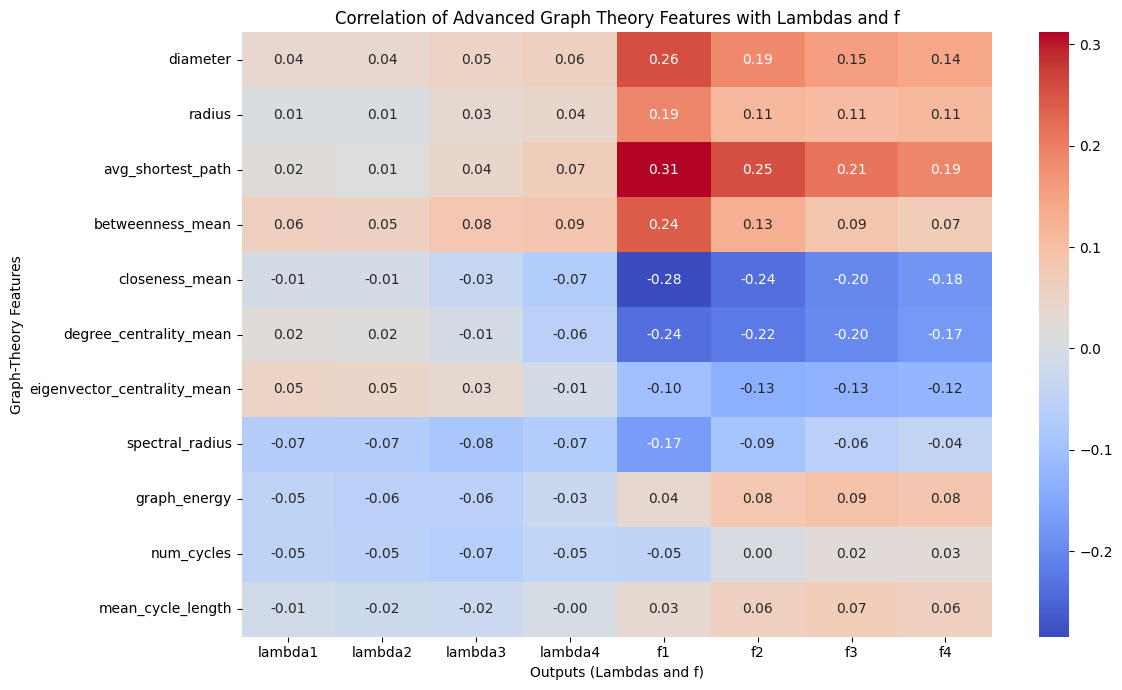

,lambda1,lambda2,lambda3,lambda4,f1,f2,f3,f4
diameter,0.037031,0.038924,0.051925,0.058892,0.258019,0.185837,0.154783,0.140445
radius,0.00572,0.005909,0.032892,0.041189,0.189647,0.109515,0.106436,0.109321
avg_shortest_path,0.019654,0.011901,0.03993,0.067217,0.311781,0.253756,0.213427,0.190638
betweenness_mean,0.061433,0.054838,0.083512,0.085113,0.241,0.128112,0.087821,0.071108
closeness_mean,-0.007031,-0.005851,-0.03344,-0.070173,-0.284348,-0.235476,-0.202065,-0.179302
degree_centrality_mean,0.02117,0.017136,-0.008821,-0.056643,-0.236187,-0.220614,-0.196092,-0.173872
eigenvector_centrality_mean,0.05058,0.045877,0.033625,-0.00897,-0.102193,-0.134165,-0.130887,-0.122894
spectral_radius,-0.06756,-0.067402,-0.084486,-0.070829,-0.16822,-0.093054,-0.057811,-0.043344
graph_energy,-0.047726,-0.056778,-0.056989,-0.027503,0.036928,0.081815,0.091248,0.084372
num_cycles,-0.048357,-0.054173,-0.065211,-0.045625,-0.048384,0.003828,0.024645,0.026293


In [41]:
df_graph = collect_advanced_graph_features(four_pair_train_ds)
corr_matrix = plot_advanced_graph_correlations(df_graph)
corr_matrix


The initial exploration of traditional graph theory features suggests a potentially promising direction for modeling, particularly in relation to the oscillator strength ($f$). A significant number of these features exhibit a measurable degree of correlation with the $f$ values. 

Observed Predictors: Metrics capturing global connectivity and molecular compactness—such as the Average Shortest Path, Diameter, Radius, and various Centrality measures (including Betweenness) - appear to be the most indicative proxies for $f$. 

A Noteworthy Divergence: A striking observation, which warrants further investigation, is the apparent lack of correlation between these highly-correlated graph features and the wavelength ($\lambda$) values. Should this divergence hold true after rigorous validation, it suggests that predicting $\lambda$ could present a substantially greater challenge than predicting $f$, as the molecule's overall structural organization (as defined by these metrics) seems primarily related to the transition probability ($f$) rather than the transition energy ($\lambda$).



It is important to acknowledge that the current graph analysis relies entirely on edges predicted based solely on atom coordinates (likely using a fixed distance threshold). This definition is not necessarily transferable across all chemical systems.A key validation step is warranted: We must investigate how changing the criteria for edge creation (e.g., using different distance thresholds or bond order information) impacts the feature space. Is the previously observed correlation between the classical graph theory features (like Average Shortest Path) and the Oscillator Strength ($f$) values robust to variations in the underlying graph structure? This is essential for ensuring the features are learning molecular principles, not just artifacts of the initial coordinate-based edge construction.

In [42]:
pair_config['transforms']['AddEdgesAndDistances']['cutoff'] = 10
print(pair_config)

four_pair_dataset_cutoff_10 = get_dataset_for(pair_config)
four_pair_train_ds_cutoff_10, _, _ = split_dataset(four_pair_dataset_cutoff_10, pair_config['split_ratios'])

{'name': 'TMQM_SPECTO', 'root_dir': 'data/datasets/TMQM_SPECTO', 'pre_transforms': {}, 'transforms': {'AddEdgesAndDistances': {'cutoff': 10}}, 'in_channels': 1, 'out_channels': 8, 'task_type': 'multiregression', 'split_ratios': [0.8, 0.1], 'metric_mode': 'min', 'main_metric': 'MAE', 'additional_loading_params': {'prediction_type': 'pairs', 'num_states': 4, 'vis_range': [380, 750], 'block_3_only': True, 'filter_type': 'all_visible_lambdas', 'min_f_value': -1, 'sort_by_max_f': True, 'standarize_lambda': True, 'standarize_f': True}}
Loading dataset 'TMQM_SPECTO' from data/datasets/TMQM_SPECTO...
{'prediction_type': 'pairs', 'num_states': 4, 'vis_range': [380, 750], 'block_3_only': True, 'filter_type': 'all_visible_lambdas', 'min_f_value': -1, 'sort_by_max_f': True, 'standarize_lambda': True, 'standarize_f': True}


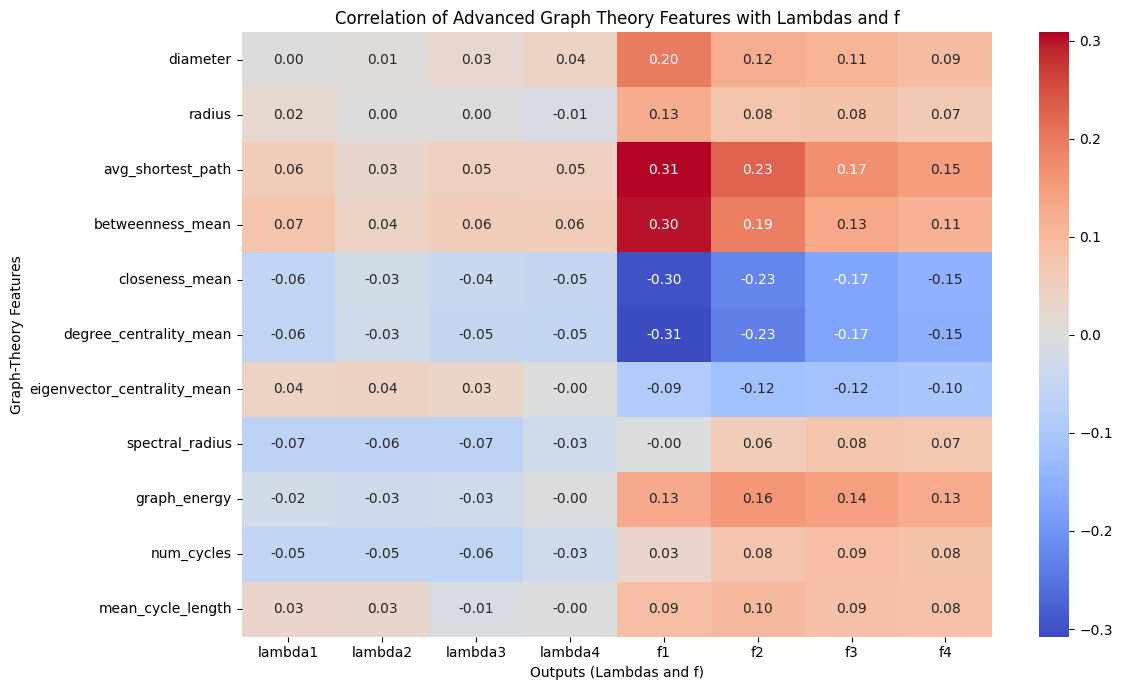

,lambda1,lambda2,lambda3,lambda4,f1,f2,f3,f4
diameter,0.004606,0.005913,0.025466,0.040392,0.196776,0.120895,0.10885,0.092524
radius,0.022233,0.003747,0.001144,-0.00943,0.125309,0.076581,0.079931,0.067514
avg_shortest_path,0.05817,0.027855,0.046337,0.048808,0.308423,0.228207,0.169222,0.147783
betweenness_mean,0.074965,0.040373,0.059122,0.057913,0.299838,0.19108,0.131987,0.114035
closeness_mean,-0.055608,-0.026136,-0.043978,-0.04921,-0.297144,-0.225269,-0.170734,-0.148505
degree_centrality_mean,-0.058114,-0.028404,-0.048288,-0.051289,-0.307795,-0.232241,-0.174559,-0.152042
eigenvector_centrality_mean,0.039667,0.044322,0.032035,-0.000275,-0.089194,-0.119333,-0.115014,-0.104901
spectral_radius,-0.065221,-0.062429,-0.066019,-0.030421,-0.001812,0.058587,0.075936,0.069726
graph_energy,-0.024802,-0.031791,-0.029949,-0.002281,0.130043,0.157196,0.144764,0.126962
num_cycles,-0.053611,-0.054695,-0.061743,-0.029479,0.031246,0.079684,0.090122,0.080547


In [43]:
df_graph_cutoff_10 = collect_advanced_graph_features(four_pair_train_ds_cutoff_10)
corr_matrix_cutoff_10 = plot_advanced_graph_correlations(df_graph_cutoff_10)
corr_matrix_cutoff_10


{'name': 'TMQM_SPECTO', 'root_dir': 'data/datasets/TMQM_SPECTO', 'pre_transforms': {}, 'transforms': {'AddEdgesAndDistances': {'cutoff': 2}}, 'in_channels': 1, 'out_channels': 8, 'task_type': 'multiregression', 'split_ratios': [0.8, 0.1], 'metric_mode': 'min', 'main_metric': 'MAE', 'additional_loading_params': {'prediction_type': 'pairs', 'num_states': 4, 'vis_range': [380, 750], 'block_3_only': True, 'filter_type': 'all_visible_lambdas', 'min_f_value': -1, 'sort_by_max_f': True, 'standarize_lambda': True, 'standarize_f': True}}
Loading dataset 'TMQM_SPECTO' from data/datasets/TMQM_SPECTO...
{'prediction_type': 'pairs', 'num_states': 4, 'vis_range': [380, 750], 'block_3_only': True, 'filter_type': 'all_visible_lambdas', 'min_f_value': -1, 'sort_by_max_f': True, 'standarize_lambda': True, 'standarize_f': True}


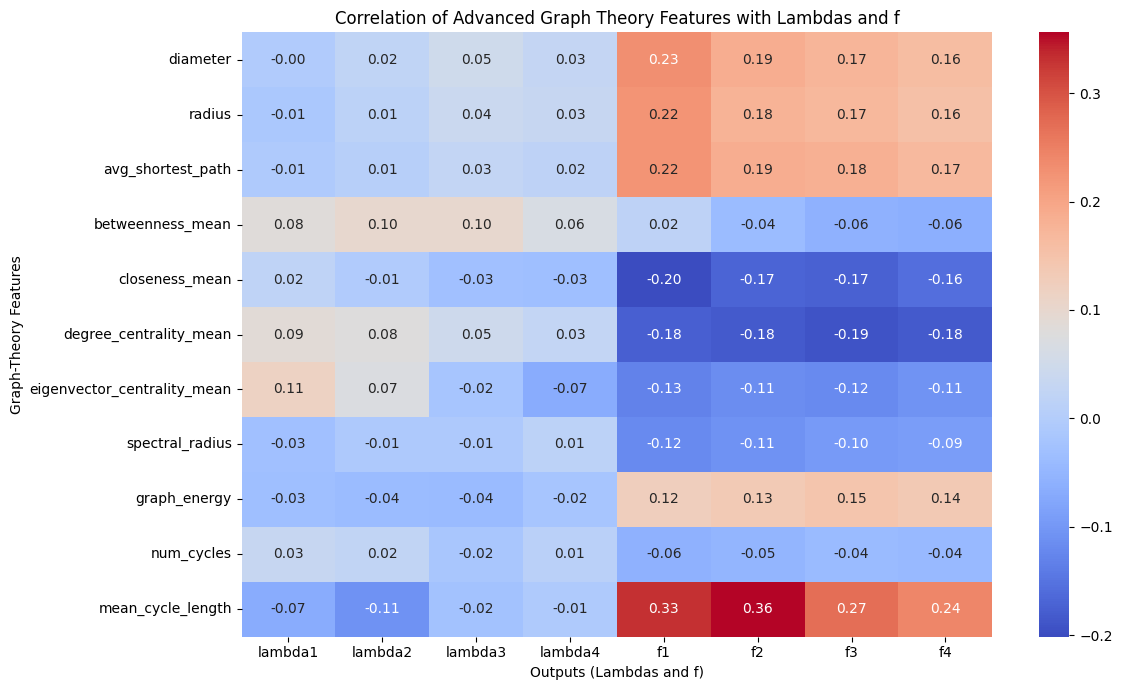

,lambda1,lambda2,lambda3,lambda4,f1,f2,f3,f4
diameter,-0.004729,0.021385,0.04748,0.028009,0.230806,0.186459,0.174237,0.161879
radius,-0.013636,0.014569,0.038357,0.033164,0.223911,0.178274,0.169639,0.155167
avg_shortest_path,-0.005517,0.006998,0.025338,0.01641,0.22437,0.186672,0.183621,0.167434
betweenness_mean,0.082631,0.099793,0.100801,0.064356,0.018327,-0.03912,-0.058917,-0.06359
closeness_mean,0.019643,-0.005032,-0.031335,-0.031635,-0.201361,-0.170283,-0.173635,-0.15666
degree_centrality_mean,0.087527,0.079263,0.045508,0.025264,-0.175916,-0.183139,-0.192227,-0.183005
eigenvector_centrality_mean,0.114661,0.071885,-0.019734,-0.06849,-0.130153,-0.114429,-0.119113,-0.106166
spectral_radius,-0.029973,-0.00914,-0.008143,0.014293,-0.119538,-0.109458,-0.095647,-0.091393
graph_energy,-0.032808,-0.039363,-0.040908,-0.01897,0.123965,0.134654,0.146883,0.136253
num_cycles,0.032818,0.024572,-0.017066,0.010039,-0.057926,-0.052746,-0.040328,-0.042433


In [45]:
pair_config['transforms']['AddEdgesAndDistances']['cutoff'] = 2
print(pair_config)

four_pair_dataset_cutoff_1 = get_dataset_for(pair_config)
four_pair_train_ds_cutoff_1, _, _ = split_dataset(four_pair_dataset_cutoff_1, pair_config['split_ratios'])

df_graph_cutoff_1 = collect_advanced_graph_features(four_pair_train_ds_cutoff_1)
corr_matrix_cutoff_1 = plot_advanced_graph_correlations(df_graph_cutoff_1)
corr_matrix_cutoff_1


## Summary

This notebook provided a wide-ranging Exploratory Data Analysis (EDA) of the TMQM dataset, identifying critical structural properties and feature relationships that will inform the subsequent modeling phase. The most important observations are summarized below:

### Target Variable Distributions and Bias
Both target features Oscillator Strength ($f$) and Wavelength ($\lambda$) - exhibit a highly exponential distribution, with a heavy concentration of values at the lower end of the spectrum (e.g., $f \approx 0$ and $\lambda < 450\text{ nm}$). This severe data bias must be explicitly accounted for during model training (e.g., through sampling, weighting, or transformation).

### Data Sparsity and Prediction Difficulty
Due to the chemical nature of the molecules, only a very small fraction of the dataset exhibits four or more significant non-zero oscillator strength ($f$) values. This inherent sparsity means that predicting the third, fourth, and subsequent transitions will likely present an exponentially greater challenge for any predictive model.

### Strong Internal Correlation and Modeling Strategy
The strongest data structure lies in the high sequential correlation observed both within the Oscillator Strength ($f$) values ($f_i$ vs. $f_{i+1}$) and within the Wavelength ($\lambda$) values ($\lambda_i$ vs. $\lambda_{i+1}$). This structure suggests exploring sequential or joint prediction models. 

### Informative Global and Geometrical Features
Simple global features that describe molecular geometry and size, such as Bounding Box Volume and Mean Pairwise Distance, show a moderate but measurable correlation with $f$ values ($\sim 0.2$ to $0.3$). This suggests that the molecule's overall size, shape, and density are important determinants of transition probability.

### Graph Structure as a Predictor
While pure edge features show minimal correlation, the classic graph theory properties (e.g., Average Shortest Path, Diameter) show a promising correlation with the $f$ values. This result strongly suggests that modeling the molecule as a graph structure (using Graph Neural Networks or feature engineering based on graph metrics) is a highly considerable option for the model input.

### The Wavelength Prediction Challenge
A critical finding is that the majority of structural features (including the beneficial graph metrics) are correlated only with $f$ values and show an apparent lack of correlation with the $\lambda$ values. This strongly indicates that the task of $\lambda$ prediction will be substantially tougher than $f$ prediction, requiring a different set of features or a specialized modeling approach.